In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['text.usetex'] = False
mpl.rcParams['font.family'] = 'Arial'
def plot_hit_enrichment_same_plot(
    plot_df,
    top_fracs=(0.05, 0.10, 0.20, 0.30, 0.40, 0.50),
    methods=None,
    out_file="",
    title="",
    show_background=True,
    point_size_range=(35, 140),   # 点更大
    palette_name="Set2",          # 更和谐；也可改成 "colorblind"
    title_fontsize=16,
    label_fontsize=16,
    tick_fontsize=16,
    legend_fontsize=16,
    linewidth=2.4
):
    if methods is None:
        method_order = plot_df["Method"].drop_duplicates().tolist()
    else:
        method_order = [m for m in methods if m in plot_df["Method"].unique()]

    palette = sns.color_palette(palette_name, n_colors=len(method_order))
    stats_rows = []

    # ---------------------------------------------
    # 先把所有统计量算出来
    # ---------------------------------------------
    for method in method_order:
        sub = plot_df.loc[plot_df["Method"] == method].copy()
        sub = sub.dropna(subset=["ml_score", "mpra_hit"]).copy()

        if len(sub) == 0:
            continue

        bg_rate = sub["mpra_hit"].mean()

        for frac in top_fracs:
            cutoff = sub["ml_score"].quantile(1 - frac)
            is_top = sub["ml_score"] >= cutoff

            a = ((is_top) & (sub["mpra_hit"])).sum()
            b = ((is_top) & (~sub["mpra_hit"])).sum()
            c = ((~is_top) & (sub["mpra_hit"])).sum()
            d = ((~is_top) & (~sub["mpra_hit"])).sum()

            top_rate = a / (a + b) if (a + b) > 0 else np.nan
            rest_rate = c / (c + d) if (c + d) > 0 else np.nan
            odds_ratio, p = fisher_exact([[a, b], [c, d]], alternative="greater")

            stats_rows.append({
                "Method": method,
                "top_fraction": frac,
                "top_percent": frac * 100,
                "n_top": a + b,
                "n_rest": c + d,
                "top_hit_rate": top_rate,
                "rest_hit_rate": rest_rate,
                "background_hit_rate": bg_rate,
                "odds_ratio": odds_ratio,
                "Fisher_p": p
            })

    stats_df = pd.DataFrame(stats_rows)

    if len(stats_df) > 0:
        stats_df["FDR"] = multipletests(stats_df["Fisher_p"], method="fdr_bh")[1]

    # ---------------------------------------------
    # 按 n_top 映射点大小
    # ---------------------------------------------
    size_min, size_max = point_size_range
    n_min = stats_df["n_top"].min()
    n_max = stats_df["n_top"].max()

    def map_point_size(n):
        if pd.isna(n):
            return (size_min + size_max) / 2
        if n_min == n_max:
            return (size_min + size_max) / 2
        return size_min + (n - n_min) / (n_max - n_min) * (size_max - size_min)

    stats_df["point_size"] = stats_df["n_top"].apply(map_point_size)

    print("\n=== MPRA hit enrichment results ===")
    print(stats_df.to_string(index=False))

    # ---------------------------------------------
    # 画图
    # ---------------------------------------------
    fig, ax = plt.subplots(figsize=(6.0, 4.8), dpi=300)

    for color, method in zip(palette, method_order):
        tmp = stats_df.loc[stats_df["Method"] == method].sort_values("top_percent").copy()

        if len(tmp) == 0:
            continue

        xvals = tmp["top_percent"].values
        yvals = tmp["top_hit_rate"].values
        svals = tmp["point_size"].values
        bg_rate = tmp["background_hit_rate"].iloc[0]

        # 线
        ax.plot(
            xvals,
            yvals,
            linewidth=linewidth,
            color=color,
            label=method,
            zorder=2
        )

        # 点
        ax.scatter(
            xvals,
            yvals,
            s=svals,
            color=color,
            edgecolor="white",
            linewidth=0.8,
            zorder=3
        )

        if show_background:
            ax.axhline(
                bg_rate,
                linestyle="--",
                linewidth=1.2,
                color=color,
                alpha=0.30
            )

    ax.set_xlabel("Top predicted variants (%)", fontsize=label_fontsize)
    ax.set_ylabel("Fraction of MPRA hits", fontsize=label_fontsize)

    if title:
        ax.set_title(title, fontsize=title_fontsize)

    ax.tick_params(axis="both", labelsize=tick_fontsize)

    ax.legend(
        frameon=False,
        fontsize=legend_fontsize,
        title="",
        loc="best"
    )

    sns.despine()
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, format="pdf", dpi=300, bbox_inches="tight")

    plt.show()
    return stats_df


def prepare_validation_df(
    df_mpra,
    score_dict,
    logfc_col="logFC_converted",
    p_col="p",
    fdr_col="fdr",
    score_transform="neglog10",   # "neglog10" or "none"
    mpra_metric="abs_logFC",      # "abs_logFC", "neglog10_p", "neglog10_fdr"
    hit_fdr_threshold=0.05,
):
    """
    Build one long-format dataframe from MPRA dataframe + one or more ML score series.
    score_dict: {method_name: pd.Series}
    """
    out = []

    for method_name, score_series in score_dict.items():
        score_series = pd.Series(score_series).rename("raw_score")

        cols_needed = [logfc_col]
        if p_col in df_mpra.columns:
            cols_needed.append(p_col)
        if fdr_col in df_mpra.columns:
            cols_needed.append(fdr_col)

        tmp = df_mpra[cols_needed].join(score_series, how="inner").copy()
        tmp = tmp.dropna(subset=["raw_score", logfc_col])

        # -------------------------
        # ML score transformation
        # -------------------------
        if score_transform == "neglog10":
            tmp = tmp[tmp["raw_score"] > 0].copy()
            tmp["ml_score"] = -np.log10(tmp["raw_score"].clip(lower=1e-300))
            score_label = r"$-log_{10}$(ML p-value)"
        elif score_transform == "none":
            tmp["ml_score"] = tmp["raw_score"]
            score_label = "ML score"
        else:
            raise ValueError("score_transform must be 'neglog10' or 'none'")

        # -------------------------
        # MPRA metric for plotting
        # -------------------------
        if mpra_metric == "abs_logFC":
            tmp["mpra_metric"] = tmp[logfc_col].abs()
            metric_label = "Absolute log fold change in MPRA"
        elif mpra_metric == "neglog10_p":
            if p_col not in tmp.columns:
                raise ValueError(f"{p_col} not found in df_mpra")
            tmp["mpra_metric"] = -np.log10(tmp[p_col].clip(lower=1e-300))
            metric_label = r"$-log_{10}$(MPRA p-value)"
        elif mpra_metric == "neglog10_fdr":
            if fdr_col not in tmp.columns:
                raise ValueError(f"{fdr_col} not found in df_mpra")
            tmp["mpra_metric"] = -np.log10(tmp[fdr_col].clip(lower=1e-300))
            metric_label = r"$-log_{10}$(MPRA FDR)"
        else:
            raise ValueError("mpra_metric must be 'abs_logFC', 'neglog10_p', or 'neglog10_fdr'")

        # -------------------------
        # MPRA hit definition
        # -------------------------
        if fdr_col not in tmp.columns:
            raise ValueError(f"{fdr_col} not found in df_mpra")
        tmp["abs_logFC"] = tmp[logfc_col].abs()
        tmp["mpra_hit"] = tmp[fdr_col] < hit_fdr_threshold
        tmp["Method"] = method_name
        out.append(tmp)

    plot_df = pd.concat(out, axis=0)

    return plot_df, score_label, metric_label

[LOGNORMAL FIT] shape=2.2278, loc=0.0000, scale=0.0439
Total data points: 855
[LOGNORMAL FIT] shape=2.3860, loc=0.0000, scale=0.0427
Total data points: 855
[LOGNORMAL FIT] shape=2.3694, loc=0.0000, scale=0.0203
Total data points: 855
[LOGNORMAL FIT] shape=2.1445, loc=0.0000, scale=0.0667
Total data points: 855
[LOGNORMAL FIT] shape=2.6758, loc=0.0000, scale=0.0331
Total data points: 855
[LOGNORMAL FIT] shape=2.3930, loc=0.0000, scale=0.0580
Total data points: 855
[LOGNORMAL FIT] shape=2.4502, loc=0.0000, scale=0.0576
Total data points: 855
[LOGNORMAL FIT] shape=2.2183, loc=0.0000, scale=0.0616
Total data points: 855
[LOGNORMAL FIT] shape=2.4455, loc=0.0000, scale=0.0474
Total data points: 855
[LOGNORMAL FIT] shape=2.3168, loc=0.0000, scale=0.0519
Total data points: 855
[LOGNORMAL FIT] shape=2.4494, loc=0.0000, scale=0.0301
Total data points: 855
[LOGNORMAL FIT] shape=3.8225, loc=0.0000, scale=0.0650
Total data points: 855
[LOGNORMAL FIT] shape=2.3973, loc=0.0000, scale=0.0360
Total dat

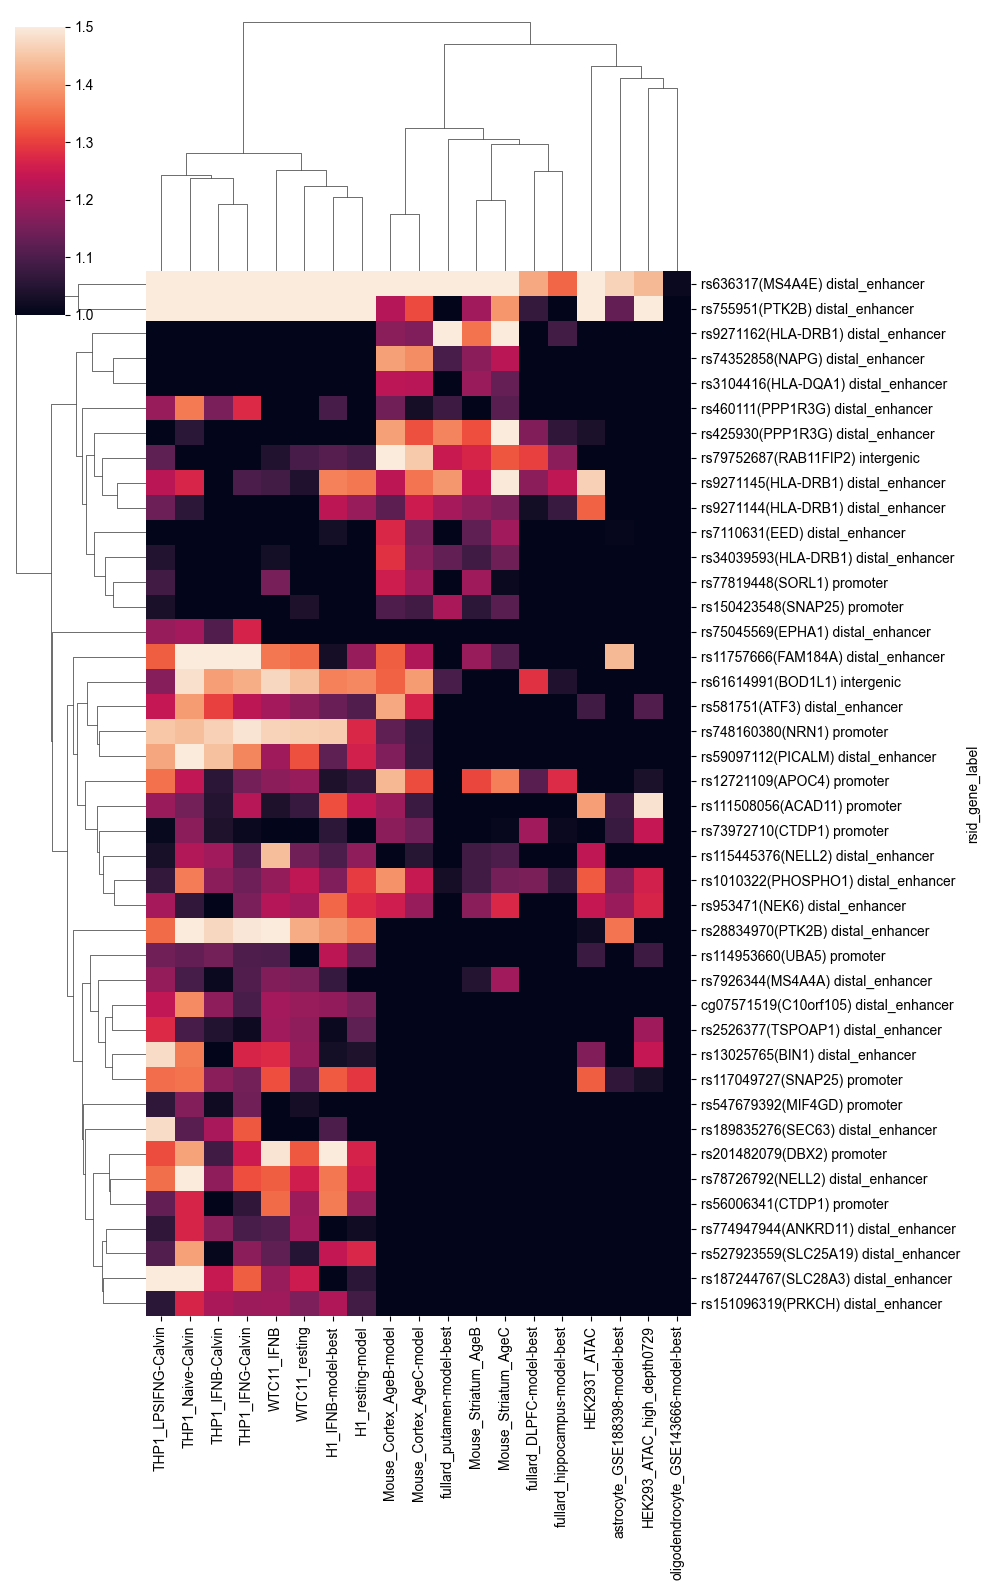

In [2]:
import pandas as pd
import numpy as np
import numpy as np
from scipy.stats import lognorm
from statsmodels.stats.multitest import multipletests
import seaborn as sns
def compute_atac_pvalues_no_fdr(
    df_pos_diff: np.ndarray,
    df_neg_diff: np.ndarray,
    index_csv_path: str
) -> pd.DataFrame:
    """
    Function to compute SHAP effect sizes and p-values for SNPs using new data inputs.

    Parameters
    ----------
    df_pos_diff : np.ndarray
        Array of SHAP effect differences from the positive set.
    df_neg_diff : np.ndarray
        Array of SHAP effect differences from the negative set (null distribution).
    index_csv_path : str
        Path to the CSV file containing at least an 'index' column.

    Returns
    -------
    pd.DataFrame
        Columns: ['index', 'SNP_SHAP_Effect_Size', 'p_value']
    """

    # Ensure input arrays have the correct length
    N = 855
    if len(df_pos_diff) != N or len(df_neg_diff) != N:
        raise ValueError(f"Expected {N} values for both positive and negative datasets, "
                         f"but got {len(df_pos_diff)} and {len(df_neg_diff)}.")

    # Compute absolute SHAP effect sizes
    summed_values = np.abs(df_pos_diff)
    summed_values_null = np.abs(df_neg_diff)

    # ----------------------------------------
    # Handle Zeroes in `summed_values_null`
    # ----------------------------------------
    min_nonzero = np.min(summed_values_null[summed_values_null > 0])  # Find smallest nonzero value
    summed_values_null[summed_values_null == 0] = min_nonzero  # Replace all zeros

    # ----------------------------------------
    # Fit Lognormal Distribution to Null
    # ----------------------------------------
    shape_ln, loc_ln, scale_ln = lognorm.fit(summed_values_null, floc=0)

    # ----------------------------------------
    # Compute P-values (Upper Tail)
    # ----------------------------------------
    pvals = 1 - lognorm.cdf(summed_values, shape_ln, loc_ln, scale_ln)

    # ----------------------------------------
    # Build and Return Results DataFrame
    # ----------------------------------------
    df_index = pd.read_csv(index_csv_path, index_col=0)
    
    df_result = pd.DataFrame({
        'SNP_SHAP_Effect_Size': summed_values,
        'p_value': pvals
    })
    df_result.index = df_index.index[:N]  # Ensure index matches

    # Log Summary
    print(f"[LOGNORMAL FIT] shape={shape_ln:.4f}, loc={loc_ln:.4f}, scale={scale_ln:.4f}")
    print(f"Total data points: {N}")

    return df_result

folders = [
    'H1_IFNB-model-best',
    'H1_resting-model',
    'HEK293_ATAC_high_depth0729',
    'HEK293T_ATAC',
    'Mouse_Cortex_AgeB-model',
    'Mouse_Cortex_AgeC-model',
    'Mouse_Striatum_AgeB',
    'Mouse_Striatum_AgeC',
    'THP1_IFNB-Calvin',
    'THP1_IFNG-Calvin',
    'THP1_LPSIFNG-Calvin',
    'THP1_monocyte0729',
    'THP1_Naive-Calvin',
    'WTC11_IFNB',
    'WTC11_resting',
    'fullard_DLPFC-model-best',
    'fullard_hippocampus-model-best',
    'fullard_putamen-model-best',
    "astrocyte_GSE188398-model-best",
    "oligodendrocyte_GSE143666-model-best"

]

pairs = []
for f in folders:
    pairs.append((
        f'prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences/{f}_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv',
        f'prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences_negative/{f}_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv',
        f
    ))

index_csv_path = '../../mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv'

all_p_values = pd.DataFrame()
all_shap_effect = pd.DataFrame()

for (file1, file2, model) in pairs:
    # Load and process the positive dataset
    df_pos = pd.read_csv(file1, header=None)
    df_pos = df_pos.groupby(df_pos.index // 2).mean()
    df_pos_diff = np.array(df_pos.loc[:854][0]) - np.array(df_pos.loc[855:][0])

    # Load and process the negative dataset
    df_neg = pd.read_csv(file2, header=None)
    df_neg = df_neg.groupby(df_neg.index // 2).mean()
    df_neg_diff = np.array(df_neg.loc[:854][0]) - np.array(df_neg.loc[855:][0])

    # Compute SHAP p-values and effect sizes
    df_result = compute_atac_pvalues_no_fdr(
        df_pos_diff=df_pos_diff,
        df_neg_diff=df_neg_diff,
        index_csv_path=index_csv_path
    )

    # Store results
    all_p_values[model] = df_result['p_value']
    all_shap_effect[model] = df_result['SNP_SHAP_Effect_Size']

df_index = pd.read_csv('../../mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv' ,index_col=0)
df_index["rsid_gene_label"] = df_index['rsID']+"("+df_index['closest_protein_coding_gene_TSS']+") "+df_index['hierarchical_label']
df_index_unique = df_index.drop_duplicates(subset=['rsID'])
unique_snp = df_index_unique.index
all_p_values_unique = all_p_values.loc[unique_snp]

all_p_values_unique.index = df_index_unique["rsid_gene_label"]
p_threshold = 0.101
'''
# Select columns that contain 'THP1'
thp1_columns = [col for col in all_p_values_unique.columns if 'THP1' in col]
thp1_columns.remove('THP1_monocyte0729')
# Find rows where all selected columns have values <= 0.05
thp1_rows = all_p_values_unique[(all_p_values_unique[thp1_columns] <= p_threshold).all(axis=1)]
mask = (all_p_values_unique['THP1_monocyte0729'] <= p_threshold) & \
       (all_p_values_unique[thp1_columns] > p_threshold).all(axis=1)

thp1_mono_rows = all_p_values_unique[mask]

# Select columns that contain 'THP1'
wtc11_columns = [col for col in all_p_values_unique.columns if 'WTC11' in col]
# Find rows where all selected columns have values <= 0.05
wtc11_rows = all_p_values_unique[(all_p_values_unique[wtc11_columns] <= p_threshold).all(axis=1)]
# Select columns that contain 'THP1'
mouse_cortex_columns = [col for col in all_p_values_unique.columns if 'Mouse_Cortex' in col]
# Find rows where all selected columns have values <= 0.05
mouse_cortex_rows = all_p_values_unique[(all_p_values_unique[mouse_cortex_columns] <= p_threshold).all(axis=1)]
# Select columns that contain 'THP1'
mouse_striatum_columns = [col for col in all_p_values_unique.columns if 'Mouse_Striatum' in col]
# Find rows where all selected columns have values <= 0.05
mouse_striatum_rows = all_p_values_unique[(all_p_values_unique[mouse_striatum_columns] <= p_threshold).all(axis=1)]

all_rows = all_p_values_unique[(all_p_values_unique<= p_threshold).all(axis=1)]

df_visualize = pd.concat([all_rows,thp1_rows,thp1_mono_rows,wtc11_rows,mouse_striatum_rows,mouse_striatum_rows] ).drop_duplicates().drop(['H1_IFNB-model', 'H1_resting-model',],axis=1)
'''
######################################################################

# Select THP1-related columns
thp1_columns = [col for col in all_p_values_unique.columns if 'THP1' in col]
if 'THP1_monocyte0729' in thp1_columns:
    thp1_columns.remove('THP1_monocyte0729')

# Find rows where all THP1-related columns meet threshold
thp1_rows = all_p_values_unique[(all_p_values_unique[thp1_columns] <= p_threshold).all(axis=1)]

# Find rows where THP1_monocyte0729-model-best_SHAP meets the threshold, but all other THP1 columns don't
mask = (all_p_values_unique['THP1_monocyte0729'] <= p_threshold) & \
       (all_p_values_unique[thp1_columns] > p_threshold).all(axis=1)
thp1_mono_rows = all_p_values_unique[mask]

no_hek_columns = [col for col in all_p_values_unique.columns if "HEK293" not in col]
hek_columns = [col for col in all_p_values_unique.columns if "HEK293" in col]
mask2 = ( 
    (all_p_values_unique[hek_columns] > p_threshold).all(axis=1) & 
    (all_p_values_unique[no_hek_columns] <= p_threshold).all(axis=1)  # At least one HEK293 column > p_threshold
)
nohek_rows = all_p_values_unique[mask2]

# Function to find significant rows based on column pattern
def filter_rows_by_keyword(df, keyword, threshold):
    cols = [col for col in df.columns if keyword in col]
    if cols:
        return df[(df[cols] <= threshold).all(axis=1)]
    return pd.DataFrame(columns=df.columns)  # Return empty DataFrame if no matching columns

mouse_rows = filter_rows_by_keyword(all_p_values_unique, 'Mouse', p_threshold)

# Apply function to find significant rows
wtc11_rows = filter_rows_by_keyword(all_p_values_unique, 'WTC11', p_threshold)
mouse_cortex_rows = filter_rows_by_keyword(all_p_values_unique, 'Mouse_Cortex', p_threshold)
mouse_striatum_rows = filter_rows_by_keyword(all_p_values_unique, 'Mouse_Striatum', p_threshold)

# Find rows where all columns meet threshold
all_rows = all_p_values_unique[(all_p_values_unique <= p_threshold).all(axis=1)]


# Define a function to sort rows based on the sum of their respective columns
def sort_rows_by_sum(df, keyword):
    cols = [col for col in df.columns if keyword in col] if keyword else df.columns.tolist()
    if cols:
        df = df.copy()
        df['sum_values'] = df[cols].sum(axis=1)
        df = df.sort_values(by='sum_values', ascending=True).drop(columns=['sum_values'])
    return df

# Sort each filtered DataFrame separately
all_rows_sorted = sort_rows_by_sum(all_rows, '')
thp1_rows_sorted = sort_rows_by_sum(thp1_rows, 'THP1')
thp1_mono_rows_sorted = sort_rows_by_sum(thp1_mono_rows, 'THP1_monocyte0729')
wtc11_rows_sorted = sort_rows_by_sum(wtc11_rows, 'WTC11')
mouse_cortex_rows_sorted = sort_rows_by_sum(mouse_cortex_rows, 'Mouse_Cortex')
mouse_striatum_rows_sorted = sort_rows_by_sum(mouse_striatum_rows, 'Mouse_Striatum')
mouse_rows_sorted = sort_rows_by_sum(mouse_rows, 'Mouse')
nohek_rows_sorted = sort_rows_by_sum(nohek_rows, 'HEK')

df_sorted_visualize = pd.concat([
    all_rows_sorted,thp1_rows_sorted,mouse_rows_sorted]).drop_duplicates()

# Drop unwanted columns safely
columns_to_drop = ['THP1_monocyte0729']
df_sorted_visualize = df_sorted_visualize.drop(columns=[col for col in columns_to_drop if col in df_sorted_visualize.columns], errors='ignore')
g = sns.clustermap(
    -np.log10(df_sorted_visualize),
    vmin=-np.log10(0.1),
    vmax=1.5,
    figsize=(10, 16),col_cluster=True,row_cluster=True
)

# Preserve ATAC-model results before the SHAP cell reuses the generic variables.
all_p_values_atac = all_p_values.copy()
all_atac_effect = all_shap_effect.copy()

print(f"Saved ATAC p-values: {all_p_values_atac.shape}")
print(f"Saved ATAC absolute effects: {all_atac_effect.shape}")


[LOGNORMAL FIT] shape=2.2309, loc=0.0000, scale=0.0346
Total data points: 855
[LOGNORMAL FIT] shape=2.3384, loc=0.0000, scale=0.0332
Total data points: 855
[LOGNORMAL FIT] shape=2.2117, loc=0.0000, scale=0.0649
Total data points: 855
[LOGNORMAL FIT] shape=2.1534, loc=0.0000, scale=0.0606
Total data points: 855
[LOGNORMAL FIT] shape=2.3182, loc=0.0000, scale=0.0583
Total data points: 855
[LOGNORMAL FIT] shape=2.2306, loc=0.0000, scale=0.0584
Total data points: 855
[LOGNORMAL FIT] shape=2.2160, loc=0.0000, scale=0.0596
Total data points: 855
[LOGNORMAL FIT] shape=2.1206, loc=0.0000, scale=0.0259
Total data points: 855
[LOGNORMAL FIT] shape=2.2069, loc=0.0000, scale=0.0475
Total data points: 855
[LOGNORMAL FIT] shape=2.1509, loc=0.0000, scale=0.0827
Total data points: 855
[LOGNORMAL FIT] shape=2.2812, loc=0.0000, scale=0.0763
Total data points: 855
[LOGNORMAL FIT] shape=2.4642, loc=0.0000, scale=0.0411
Total data points: 855
[LOGNORMAL FIT] shape=2.1424, loc=0.0000, scale=0.0544
Total dat

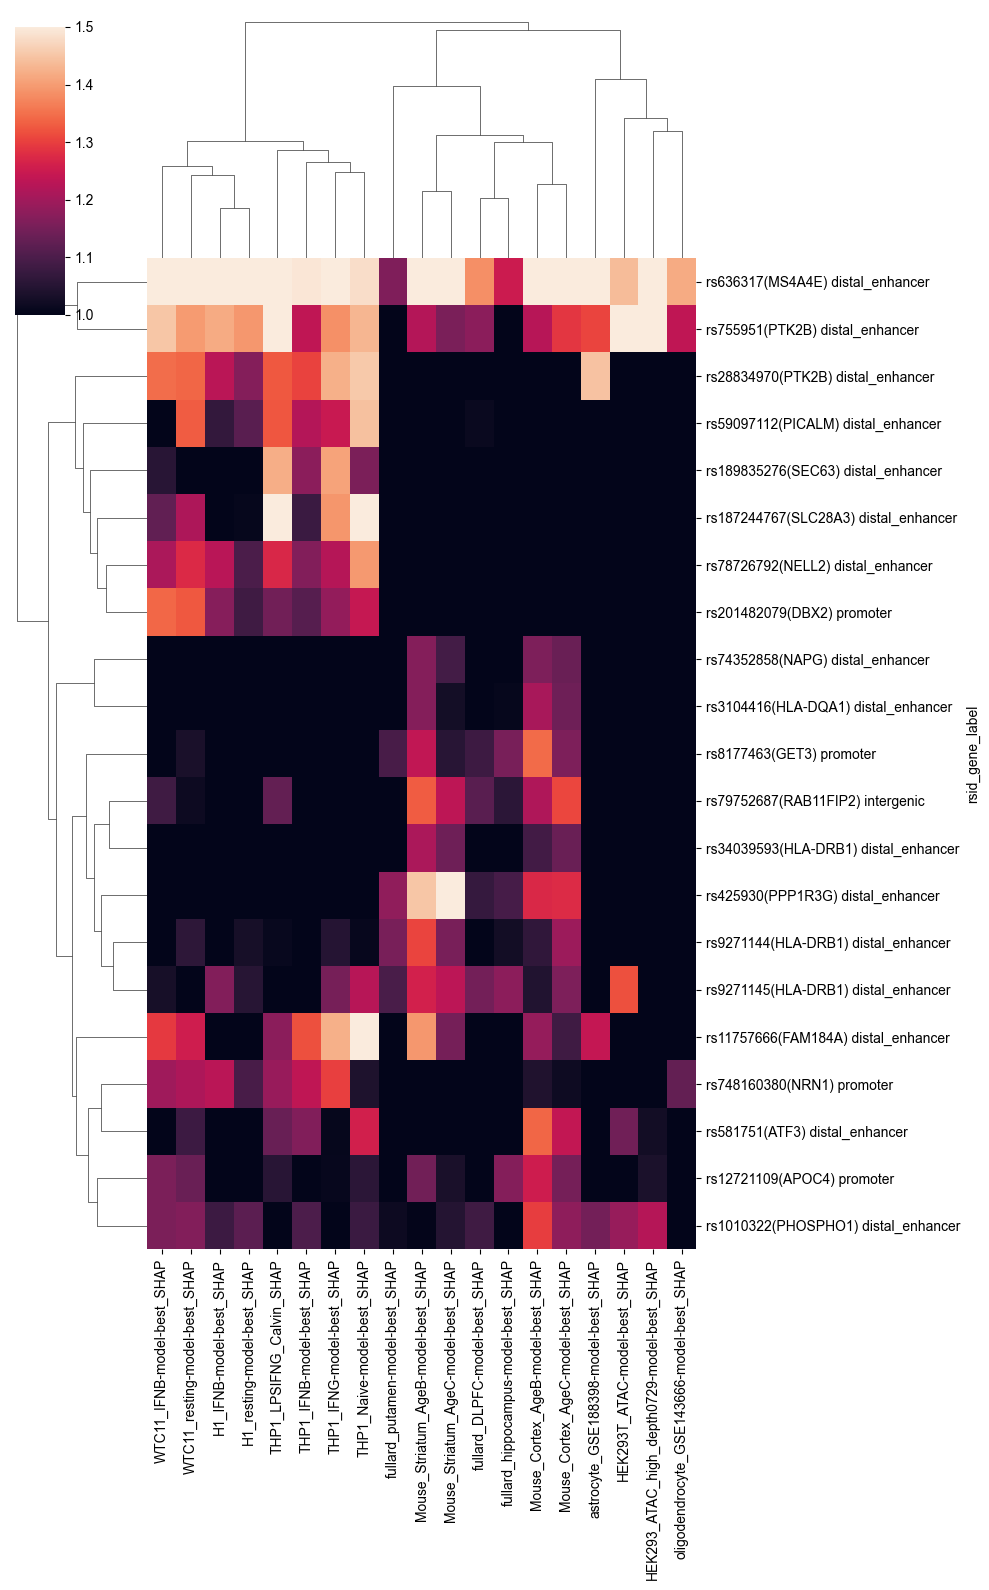

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import lognorm

def compute_shap_pvalues_no_fdr(
    npz_file_path_major_minor: str,
    npz_file_path_major_minor_null: str,
    index_csv_path: str,
    distance: int = 0
) -> pd.DataFrame:
    """
    Function to compute SHAP effect sizes and p-values for SNPs.

    Parameters
    ----------
    npz_file_path_major_minor : str
        Path to the first .npz file (major/minor).
    npz_file_path_major_minor_null : str
        Path to the second .npz file (major/minor) for the null distribution.
    index_csv_path : str
        Path to the CSV file containing at least an 'index' column.
    distance : int, optional
        Flanking distance around position 250 (default=0 => only position 250).

    Returns
    -------
    pd.DataFrame
        Columns: ['index', 'SNP_SHAP_Effect_Size', 'p_value']
    """

    def split_shap(shap_scores_squeezed, distance=0):
        """Splits SHAP values into left, SNP, and right based on distance."""
        if distance != 0:
            left = shap_scores_squeezed[:, :, (250 - distance):250]
            snp = shap_scores_squeezed[:, :, 250]
            right = shap_scores_squeezed[:, :, 251:(251 + distance)]
            return left, snp, right
        else:
            snp = shap_scores_squeezed[:, :, 250]
            return None, snp, None

    # ----------------------------------------
    # 1. Load SHAP arrays
    # ----------------------------------------
    shap_data_1 = np.load(npz_file_path_major_minor)
    shap_data_2 = np.load(npz_file_path_major_minor_null)

    shap_scores_squeezed_1 = np.squeeze(shap_data_1['arr_0'])
    shap_scores_squeezed_2 = np.squeeze(shap_data_2['arr_0'])

    # Number of SNPs
    N = 855

    # Extract major/minor SHAP values
    shap_scores_major_1 = shap_scores_squeezed_1[:N, :, :]
    shap_scores_minor_1 = shap_scores_squeezed_1[N:, :, :]
    shap_scores_major_2 = shap_scores_squeezed_2[:N, :, :]
    shap_scores_minor_2 = shap_scores_squeezed_2[N:, :, :]

    # ----------------------------------------
    # 2. Compute SHAP Differences
    # ----------------------------------------
    left_major, snp_major, right_major = split_shap(shap_scores_major_1, distance)
    left_minor, snp_minor, right_minor = split_shap(shap_scores_minor_1, distance)

    left_major_null, snp_major_null, right_major_null = split_shap(shap_scores_major_2, distance)
    left_minor_null, snp_minor_null, right_minor_null = split_shap(shap_scores_minor_2, distance)

    if left_major is not None:
        left_diff = np.sum(left_major - left_minor, axis=1)
        right_diff = np.sum(right_major - right_minor, axis=1)
        snp_diff = (np.sum(snp_major, axis=1) - np.sum(snp_minor, axis=1)).reshape(N, 1)
        shap_scores_diff = np.concatenate((left_diff, snp_diff, right_diff), axis=1)
        
        left_diff_null = np.sum(left_major_null - left_minor_null, axis=1)
        right_diff_null = np.sum(right_major_null - right_minor_null, axis=1)
        snp_diff_null = (np.sum(snp_major_null, axis=1) - np.sum(snp_minor_null, axis=1)).reshape(N, 1)
        shap_scores_diff_null = np.concatenate((left_diff_null, snp_diff_null, right_diff_null), axis=1)
    else:
        snp_diff = (np.sum(snp_major, axis=1) - np.sum(snp_minor, axis=1)).reshape(N, 1)
        shap_scores_diff = snp_diff

        snp_diff_null = (np.sum(snp_major_null, axis=1) - np.sum(snp_minor_null, axis=1)).reshape(N, 1)
        shap_scores_diff_null = snp_diff_null

    # ----------------------------------------
    # 3. Normalize & Compute Summed Values
    # ----------------------------------------
    divisor = (distance * 2 + 1) if distance != 0 else 1
    sliced_array = shap_scores_diff / divisor
    sliced_array_null = shap_scores_diff_null / divisor

    summed_values = np.sum(np.abs(sliced_array), axis=1)
    summed_values_null = np.sum(np.abs(sliced_array_null), axis=1)

    # ----------------------------------------
    # 4. Replace Zeroes in `summed_values_null`
    # ----------------------------------------
    min_nonzero = np.min(summed_values_null[summed_values_null > 0])  # Find smallest nonzero value
    summed_values_null[summed_values_null == 0] = min_nonzero  # Replace all zeros

    # ----------------------------------------
    # 5. Fit Lognormal Distribution to Null
    # ----------------------------------------
    shape_ln, loc_ln, scale_ln = lognorm.fit(summed_values_null, floc=0)

    # ----------------------------------------
    # 6. Compute P-values (Upper Tail)
    # ----------------------------------------
    pvals = 1 - lognorm.cdf(summed_values, shape_ln, loc_ln, scale_ln)

    # ----------------------------------------
    # 7. Build and Return Results DataFrame
    # ----------------------------------------
    df_index = pd.read_csv(index_csv_path, index_col=0)
    
    df_result = pd.DataFrame({
        'SNP_SHAP_Effect_Size': summed_values,
        'p_value': pvals
    })
    df_result.index = df_index.index[:N]  # Ensure index matches

    # Log Summary
    print(f"[LOGNORMAL FIT] shape={shape_ln:.4f}, loc={loc_ln:.4f}, scale={scale_ln:.4f}")
    print(f"Total data points: {N}")

    return df_result


folders = ['fullard_DLPFC-model-best_SHAP', 'fullard_hippocampus-model-best_SHAP','fullard_putamen-model-best_SHAP','H1_IFNB-model-best_SHAP',                     'THP1_IFNB-model-best_SHAP',
'H1_resting-model-best_SHAP',                  'THP1_IFNG-model-best_SHAP',
'HEK293_ATAC_high_depth0729-model-best_SHAP',  'THP1_LPSIFNG_Calvin_SHAP',
'HEK293T_ATAC-model-best_SHAP',                'THP1_monocyte0729-model-best_SHAP',
'Mouse_Cortex_AgeB-model-best_SHAP',           'THP1_Naive-model-best_SHAP',
'Mouse_Cortex_AgeC-model-best_SHAP',           'WTC11_IFNB-model-best_SHAP',
'Mouse_Striatum_AgeB-model-best_SHAP',         'WTC11_resting-model-best_SHAP',
'Mouse_Striatum_AgeC-model-best_SHAP','oligodendrocyte_GSE143666-model-best_SHAP','astrocyte_GSE188398-model-best_SHAP'
]
pairs = []
for f in folders:
    pairs.append((
        f'../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp/{f}/attributions_from_shap.npz',
        f'../../THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp_negative_snp/{f}/attributions_from_shap.npz',
        f
    ))

index_csv_path = '../../mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv'

all_p_values = pd.DataFrame()
all_shap_effect = pd.DataFrame()
for (file1, file2,model) in pairs:
    df_result = compute_shap_pvalues_no_fdr(
        npz_file_path_major_minor=file1,
        npz_file_path_major_minor_null=file2,
        index_csv_path=index_csv_path,
        distance=0  # or use something else
    )
    # you can store or save df_result
    all_p_values[model] = df_result['p_value']
    all_shap_effect[model] = df_result['SNP_SHAP_Effect_Size']


df_index = pd.read_csv('../../mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv' ,index_col=0)
df_index["rsid_gene_label"] = df_index['rsID']+"("+df_index['closest_protein_coding_gene_TSS']+") "+df_index['hierarchical_label']
df_index_unique = df_index.drop_duplicates(subset=['rsID'])
unique_snp = df_index_unique.index
all_p_values_unique = all_p_values.loc[unique_snp]

all_p_values_unique.index = df_index_unique["rsid_gene_label"]
p_threshold = 0.101
'''
# Select columns that contain 'THP1'
thp1_columns = [col for col in all_p_values_unique.columns if 'THP1' in col]
thp1_columns.remove('THP1_monocyte0729-model-best_SHAP')
# Find rows where all selected columns have values <= 0.05
thp1_rows = all_p_values_unique[(all_p_values_unique[thp1_columns] <= p_threshold).all(axis=1)]
mask = (all_p_values_unique['THP1_monocyte0729-model-best_SHAP'] <= p_threshold) & \
       (all_p_values_unique[thp1_columns] > p_threshold).all(axis=1)

thp1_mono_rows = all_p_values_unique[mask]

# Select columns that contain 'THP1'
wtc11_columns = [col for col in all_p_values_unique.columns if 'WTC11' in col]
# Find rows where all selected columns have values <= 0.05
wtc11_rows = all_p_values_unique[(all_p_values_unique[wtc11_columns] <= p_threshold).all(axis=1)]
# Select columns that contain 'THP1'
mouse_cortex_columns = [col for col in all_p_values_unique.columns if 'Mouse_Cortex' in col]
# Find rows where all selected columns have values <= 0.05
mouse_cortex_rows = all_p_values_unique[(all_p_values_unique[mouse_cortex_columns] <= p_threshold).all(axis=1)]
# Select columns that contain 'THP1'
mouse_striatum_columns = [col for col in all_p_values_unique.columns if 'Mouse_Striatum' in col]
# Find rows where all selected columns have values <= 0.05
mouse_striatum_rows = all_p_values_unique[(all_p_values_unique[mouse_striatum_columns] <= p_threshold).all(axis=1)]

all_rows = all_p_values_unique[(all_p_values_unique<= p_threshold).all(axis=1)]

df_visualize = pd.concat([all_rows,thp1_rows,thp1_mono_rows,wtc11_rows,mouse_striatum_rows,mouse_striatum_rows] ).drop_duplicates().drop(['H1_IFNB-model-best_SHAP', 'H1_resting-model-best_SHAP',],axis=1)
'''
####################################################################################################################################
import numpy as np
import pandas as pd
import seaborn as sns

# 1) Identify relevant columns
thp1_columns = [
    c for c in all_p_values_unique.columns
    if 'THP1' in c and c != 'THP1_monocyte0729-model-best_SHAP'
]
hek_columns = [c for c in all_p_values_unique.columns if 'HEK293' in c]
no_hek_columns = [c for c in all_p_values_unique.columns if 'HEK293' not in c]

# 2) Filter DataFrames
thp1_rows = all_p_values_unique[
    (all_p_values_unique[thp1_columns] <= p_threshold).all(axis=1)
]

thp1_mono_mask = (
    (all_p_values_unique['THP1_monocyte0729-model-best_SHAP'] <= p_threshold) &
    (all_p_values_unique[thp1_columns] > p_threshold).all(axis=1)
)
thp1_mono_rows = all_p_values_unique[thp1_mono_mask]

nohek_mask = (
    (all_p_values_unique[hek_columns] > p_threshold).all(axis=1) &
    (all_p_values_unique[no_hek_columns] <= p_threshold).all(axis=1)
)
nohek_rows = all_p_values_unique[nohek_mask]

# 3) Helper function to filter rows by keyword
def filter_rows_by_keyword(df, keyword, threshold):
    """
    Return rows for which all columns containing `keyword`
    are <= threshold. Returns an empty DataFrame if none found.
    """
    cols = df.filter(like=keyword)
    if cols.empty:
        return df.iloc[0:0]  # empty DataFrame with same columns
    return df[(cols <= threshold).all(axis=1)]

mouse_rows = filter_rows_by_keyword(all_p_values_unique, 'Mouse', p_threshold)
wtc11_rows = filter_rows_by_keyword(all_p_values_unique, 'WTC11', p_threshold)
mouse_cortex_rows = filter_rows_by_keyword(all_p_values_unique, 'Mouse_Cortex', p_threshold)
mouse_striatum_rows = filter_rows_by_keyword(all_p_values_unique, 'Mouse_Striatum', p_threshold)

# 4) Find rows meeting threshold in all columns
all_rows = all_p_values_unique[
    (all_p_values_unique <= p_threshold).all(axis=1)
]

# 5) Sorting function
def sort_rows_by_sum(df, keyword=None):
    """
    Sort rows by the sum of columns containing `keyword`.
    If `keyword=None`, sort by the sum across all columns.
    """
    # If keyword is given, filter columns by that keyword; else use all columns
    cols = df.filter(like=keyword).columns if keyword else df.columns
    if cols.empty:
        return df

    out = df.copy()
    out['sum_values'] = out[cols].sum(axis=1)
    out = out.sort_values('sum_values').drop(columns='sum_values')
    return out

# 6) Sort each subset
all_rows_sorted = sort_rows_by_sum(all_rows)
thp1_rows_sorted = sort_rows_by_sum(thp1_rows, 'THP1')
thp1_mono_rows_sorted = sort_rows_by_sum(thp1_mono_rows, 'THP1_monocyte0729')
nohek_rows_sorted = sort_rows_by_sum(nohek_rows, 'HEK')
wtc11_rows_sorted = sort_rows_by_sum(wtc11_rows, 'WTC11')
mouse_rows_sorted = sort_rows_by_sum(mouse_rows, 'Mouse')
mouse_cortex_rows_sorted = sort_rows_by_sum(mouse_cortex_rows, 'Mouse_Cortex')
mouse_striatum_rows_sorted = sort_rows_by_sum(mouse_striatum_rows, 'Mouse_Striatum')

# 7) Concatenate subsets for visualization
df_sorted_visualize = pd.concat([
    all_rows_sorted,
    thp1_rows_sorted,
    mouse_rows_sorted,
]).drop_duplicates()

# 8) Drop undesired columns if they exist
columns_to_drop = [
 #   'H1_IFNB-model-best_SHAP',
 #   'H1_resting-model-best_SHAP',
    'THP1_monocyte0729-model-best_SHAP'
]
df_sorted_visualize = df_sorted_visualize.drop(
    columns=[c for c in columns_to_drop if c in df_sorted_visualize],
    errors='ignore'
)

# 9) Create cluster map
g = sns.clustermap(
    -np.log10(df_sorted_visualize),
    vmin=-np.log10(0.1),
    vmax=1.5,
    figsize=(10, 16),
    col_cluster=True,
    row_cluster=True
)

# Preserve SHAP-model results under names distinct from the ATAC results.
all_p_values_shap = all_p_values.copy()
all_shap_effect_final = all_shap_effect.copy()

print(f"Saved SHAP p-values: {all_p_values_shap.shape}")
print(f"Saved SHAP absolute effects: {all_shap_effect_final.shape}")


=== MPRA hit enrichment results ===
                      Method  top_fraction  top_percent  n_top  n_rest  top_hit_rate  rest_hit_rate  background_hit_rate  odds_ratio  Fisher_p     FDR  point_size
    SHAP Brain Tissue Models          0.05          5.0     43     812      0.162791       0.224138             0.221053    0.673077  0.873985 0.97946   35.000000
    SHAP Brain Tissue Models          0.06          6.0     52     803      0.134615       0.226650             0.221053    0.530769  0.963768 0.97946   37.506631
    SHAP Brain Tissue Models          0.07          7.0     60     795      0.150000       0.226415             0.221053    0.602941  0.943117 0.97946   39.734748
    SHAP Brain Tissue Models          0.08          8.0     69     786      0.173913       0.225191             0.221053    0.724353  0.873714 0.97946   42.241379
    SHAP Brain Tissue Models          0.09          9.0     77     778      0.181818       0.224936             0.221053    0.765714  0.844947 0.979

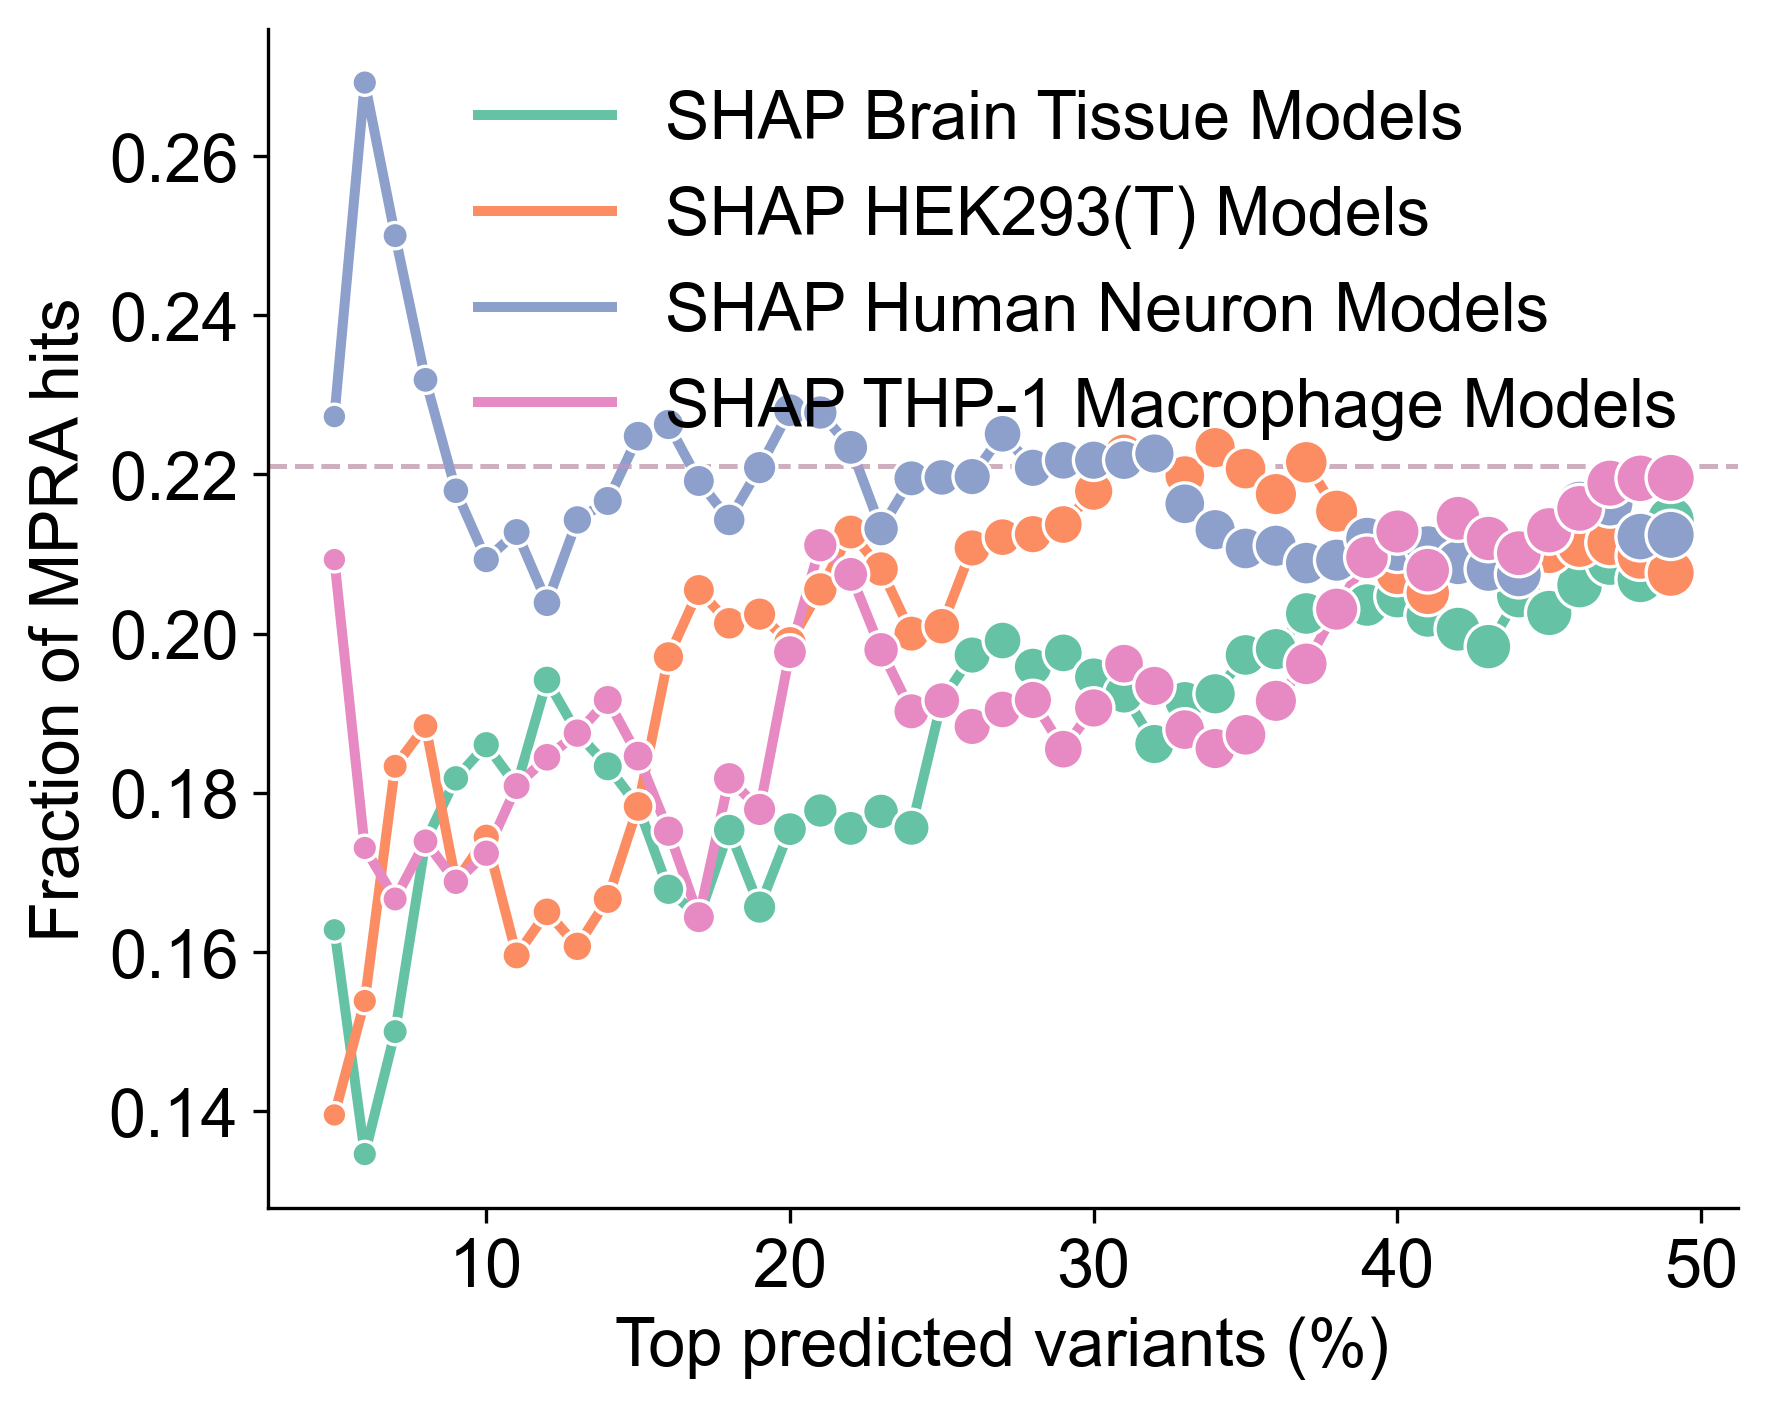

In [4]:
df = pd.read_csv(
    "../../mpra3_lib_analysis/allele_differences_withoutcontrol/"
    "20240817_allele_only_for_plotting/"
    "annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv",
    index_col=0,
)

score_dict = {

    "SHAP Brain Tissue Models": all_p_values_shap[
    [
    'Mouse_Cortex_AgeB-model-best_SHAP',
       'Mouse_Cortex_AgeC-model-best_SHAP',
       'Mouse_Striatum_AgeB-model-best_SHAP', 
       'Mouse_Striatum_AgeC-model-best_SHAP'
    ]
].min(axis=1),
    "SHAP HEK293(T) Models": all_p_values_shap[
    [
         'HEK293T_ATAC-model-best_SHAP',
            'HEK293_ATAC_high_depth0729-model-best_SHAP'
    ]
].min(axis=1),
    "SHAP Human Neuron Models": all_p_values_shap[
        [
          'fullard_DLPFC-model-best_SHAP', 
          'fullard_hippocampus-model-best_SHAP',
       'fullard_putamen-model-best_SHAP'
        ]
    ].min(axis=1),
        "SHAP THP-1 Macrophage Models": all_p_values_shap[
        [
          'THP1_IFNB-model-best_SHAP', 
       'THP1_IFNG-model-best_SHAP',
       'THP1_LPSIFNG_Calvin_SHAP',
       'THP1_Naive-model-best_SHAP'

        ]
    ].min(axis=1),
}
plot_df, score_label, metric_label = prepare_validation_df(
    df_mpra=df,
    score_dict=score_dict,
    logfc_col="logFC_converted",
    p_col="p",
    fdr_col="fdr",
    score_transform="neglog10",
    mpra_metric="abs_logFC",
    hit_fdr_threshold=0.05,
)
enrich_stats = plot_hit_enrichment_same_plot(
    plot_df,
    top_fracs=np.arange(0.05, 0.5, 0.01),
    out_file="Fig_same_plot_SHAP_neuron_vs_immune_brain_MPRA_shap.pdf",
    title="",
    show_background=True
)



=== MPRA hit enrichment results ===
                      Method  top_fraction  top_percent  n_top  n_rest  top_hit_rate  rest_hit_rate  background_hit_rate  odds_ratio  Fisher_p      FDR  point_size
    ATAC Brain Tissue Models          0.05          5.0     43     812      0.186047       0.222906             0.221053    0.796843  0.770881 0.994371   35.000000
    ATAC Brain Tissue Models          0.06          6.0     52     803      0.211538       0.221669             0.221053    0.942039  0.624400 0.994371   37.513298
    ATAC Brain Tissue Models          0.07          7.0     60     795      0.200000       0.222642             0.221053    0.872881  0.708990 0.994371   39.747340
    ATAC Brain Tissue Models          0.08          8.0     69     786      0.188406       0.223919             0.221053    0.804586  0.795439 0.994371   42.260638
    ATAC Brain Tissue Models          0.09          9.0     77     778      0.194805       0.223650             0.221053    0.839822  0.762672 

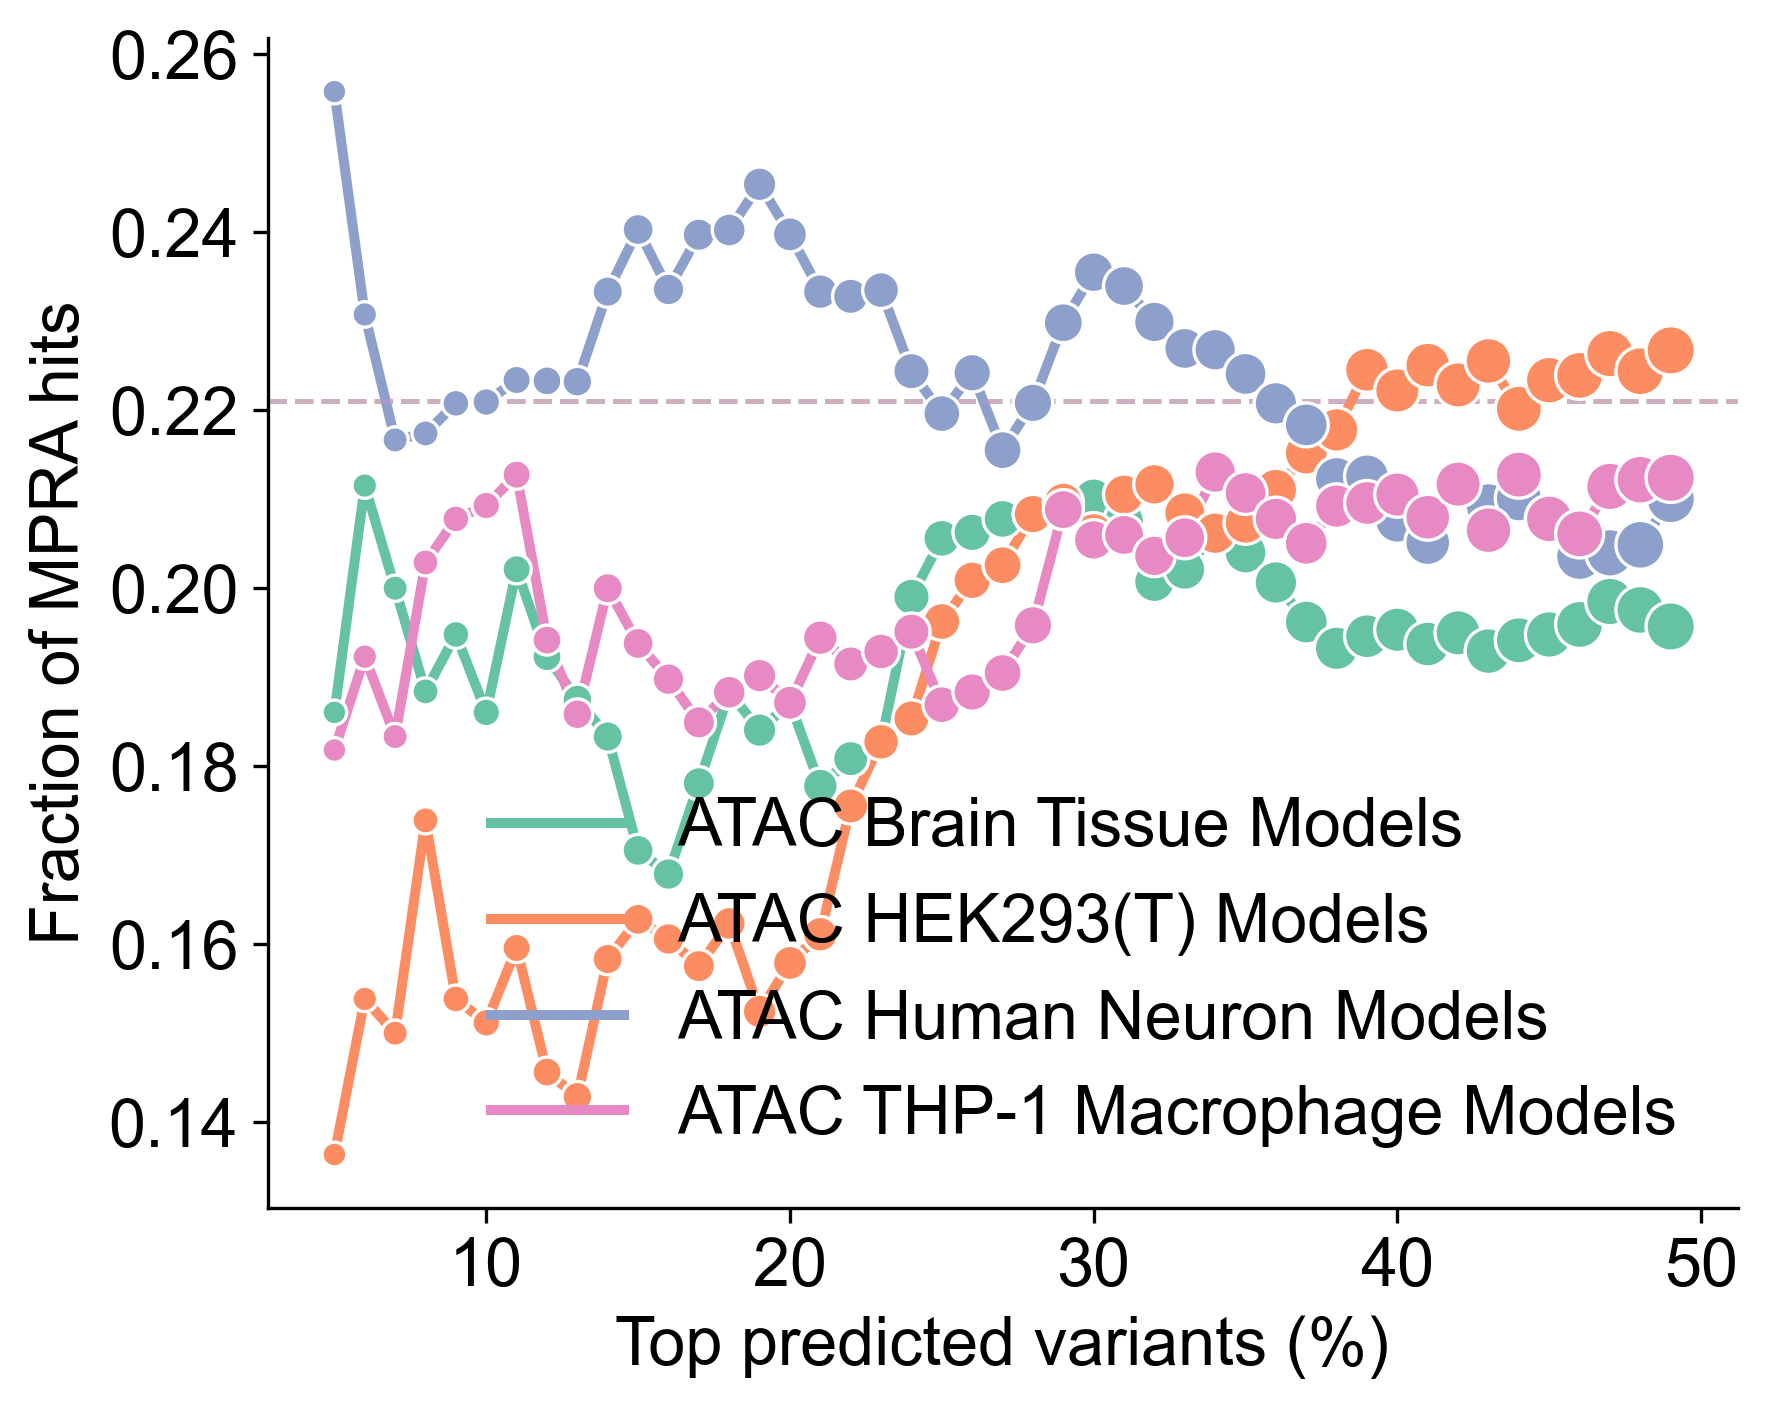

In [5]:
df = pd.read_csv(
    "../../mpra3_lib_analysis/allele_differences_withoutcontrol/"
    "20240817_allele_only_for_plotting/"
    "annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv",
    index_col=0,
)

score_dict = {

    "ATAC Brain Tissue Models": all_p_values_atac[
    [
    'Mouse_Cortex_AgeB-model',
       'Mouse_Cortex_AgeC-model',
       'Mouse_Striatum_AgeB', 
       'Mouse_Striatum_AgeC'
    ]
].min(axis=1),
    "ATAC HEK293(T) Models": all_p_values_atac[
    [
         'HEK293T_ATAC',
            'HEK293_ATAC_high_depth0729'
    ]
].min(axis=1),
    "ATAC Human Neuron Models": all_p_values_atac[
        [
          'fullard_DLPFC-model-best', 
          'fullard_hippocampus-model-best',
          'fullard_putamen-model-best'
        ]
    ].min(axis=1),
        "ATAC THP-1 Macrophage Models": all_p_values_atac[
        [
        'THP1_IFNB-Calvin', 
       'THP1_IFNG-Calvin',
       'THP1_LPSIFNG-Calvin',
       'THP1_Naive-Calvin'

        ]
    ].min(axis=1),
}
plot_df, score_label, metric_label = prepare_validation_df(
    df_mpra=df,
    score_dict=score_dict,
    logfc_col="logFC_converted",
    p_col="p",
    fdr_col="fdr",
    score_transform="neglog10",
    mpra_metric="abs_logFC",
    hit_fdr_threshold=0.05,
)
enrich_stats = plot_hit_enrichment_same_plot(
    plot_df,
    top_fracs=np.arange(0.05, 0.5, 0.01),
    out_file="Fig_same_plot_ATAC_neuron_vs_immune_brain_MPRA_atac.pdf",
    title="",
    show_background=True
)



=== MPRA hit enrichment results ===
                      Method  top_fraction  top_percent  n_top  n_rest  top_hit_rate  rest_hit_rate  background_hit_rate  odds_ratio  Fisher_p      FDR  point_size
    SHAP Brain Tissue Models          0.05          5.0     43     812      0.418605       0.412562             0.412865    1.025194  0.528694 0.829247   35.000000
    SHAP Brain Tissue Models          0.06          6.0     52     803      0.442308       0.410959             0.412865    1.136782  0.379784 0.829247   37.506631
    SHAP Brain Tissue Models          0.07          7.0     60     795      0.433333       0.411321             0.412865    1.094441  0.419054 0.829247   39.734748
    SHAP Brain Tissue Models          0.08          8.0     69     786      0.434783       0.410941             0.412865    1.102643  0.395994 0.829247   42.241379
    SHAP Brain Tissue Models          0.09          9.0     77     778      0.415584       0.412596             0.412865    1.012392  0.525781 

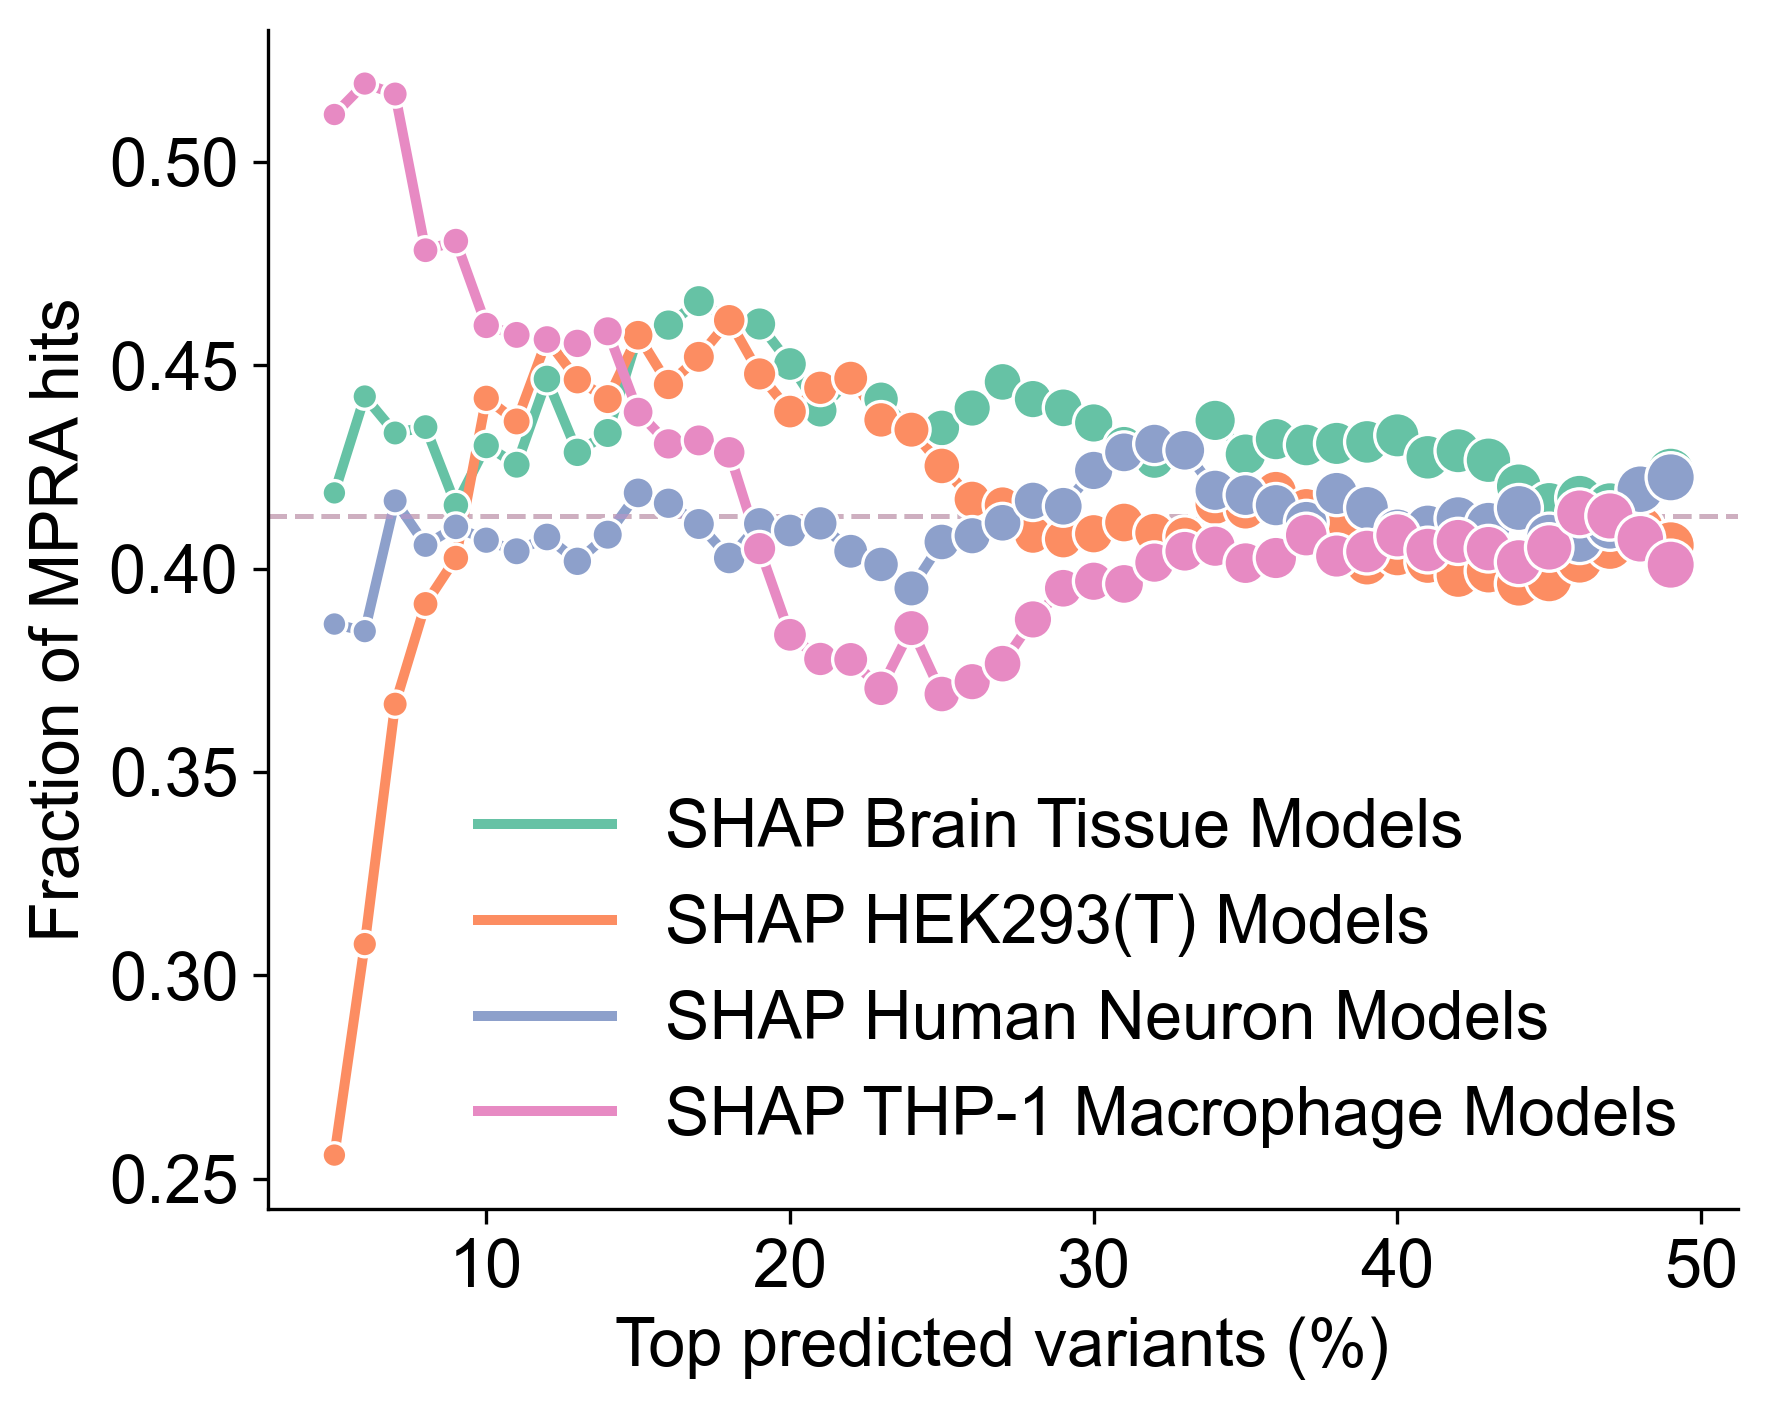

In [6]:
df = pd.read_csv(
    "../../mpra3_lib_analysis/allele_differences_withoutcontrol/"
    "20240817_allele_only_for_plotting/"
    "annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv",
    index_col=0,
)
score_dict = {

    "SHAP Brain Tissue Models": all_p_values_shap[
    [
    'Mouse_Cortex_AgeB-model-best_SHAP',
       'Mouse_Cortex_AgeC-model-best_SHAP',
       'Mouse_Striatum_AgeB-model-best_SHAP', 
       'Mouse_Striatum_AgeC-model-best_SHAP'
    ]
].min(axis=1),
    "SHAP HEK293(T) Models": all_p_values_shap[
    [
         'HEK293T_ATAC-model-best_SHAP',
            'HEK293_ATAC_high_depth0729-model-best_SHAP'
    ]
].min(axis=1),
    "SHAP Human Neuron Models": all_p_values_shap[
        [
          'fullard_DLPFC-model-best_SHAP', 
          'fullard_hippocampus-model-best_SHAP',
       'fullard_putamen-model-best_SHAP'
        ]
    ].min(axis=1),
        "SHAP THP-1 Macrophage Models": all_p_values_shap[
        [
          'THP1_IFNB-model-best_SHAP', 
       'THP1_IFNG-model-best_SHAP',
       'THP1_LPSIFNG_Calvin_SHAP',
       'THP1_Naive-model-best_SHAP'

        ]
    ].min(axis=1),
}
plot_df, score_label, metric_label = prepare_validation_df(
    df_mpra=df,
    score_dict=score_dict,
    logfc_col="logFC_converted",
    p_col="p",
    fdr_col="fdr",
    score_transform="neglog10",
    mpra_metric="abs_logFC",
    hit_fdr_threshold=0.05,
)
enrich_stats = plot_hit_enrichment_same_plot(
    plot_df,
    top_fracs=np.arange(0.05, 0.5, 0.01),
    out_file="Fig_same_plot_SHAP_neuron_vs_immune_thp1_MPRA.pdf",
    title="",
    show_background=True
)



=== MPRA hit enrichment results ===
                    Method  top_fraction  top_percent  n_top  n_rest  top_hit_rate  rest_hit_rate  background_hit_rate  odds_ratio  Fisher_p      FDR  point_size
  ATAC Human Neuron Models          0.05          5.0     43     812      0.255814       0.219212             0.221053    1.224368  0.343912 0.856115   35.000000
  ATAC Human Neuron Models          0.06          6.0     52     803      0.230769       0.220423             0.221053    1.061017  0.487896 0.856115   37.513298
  ATAC Human Neuron Models          0.07          7.0     60     795      0.216667       0.221384             0.221053    0.972800  0.587535 0.856115   39.747340
  ATAC Human Neuron Models          0.08          8.0     69     786      0.217391       0.221374             0.221053    0.977011  0.581108 0.856115   42.260638
  ATAC Human Neuron Models          0.09          9.0     77     778      0.220779       0.221080             0.221053    0.998256  0.550973 0.856115   4

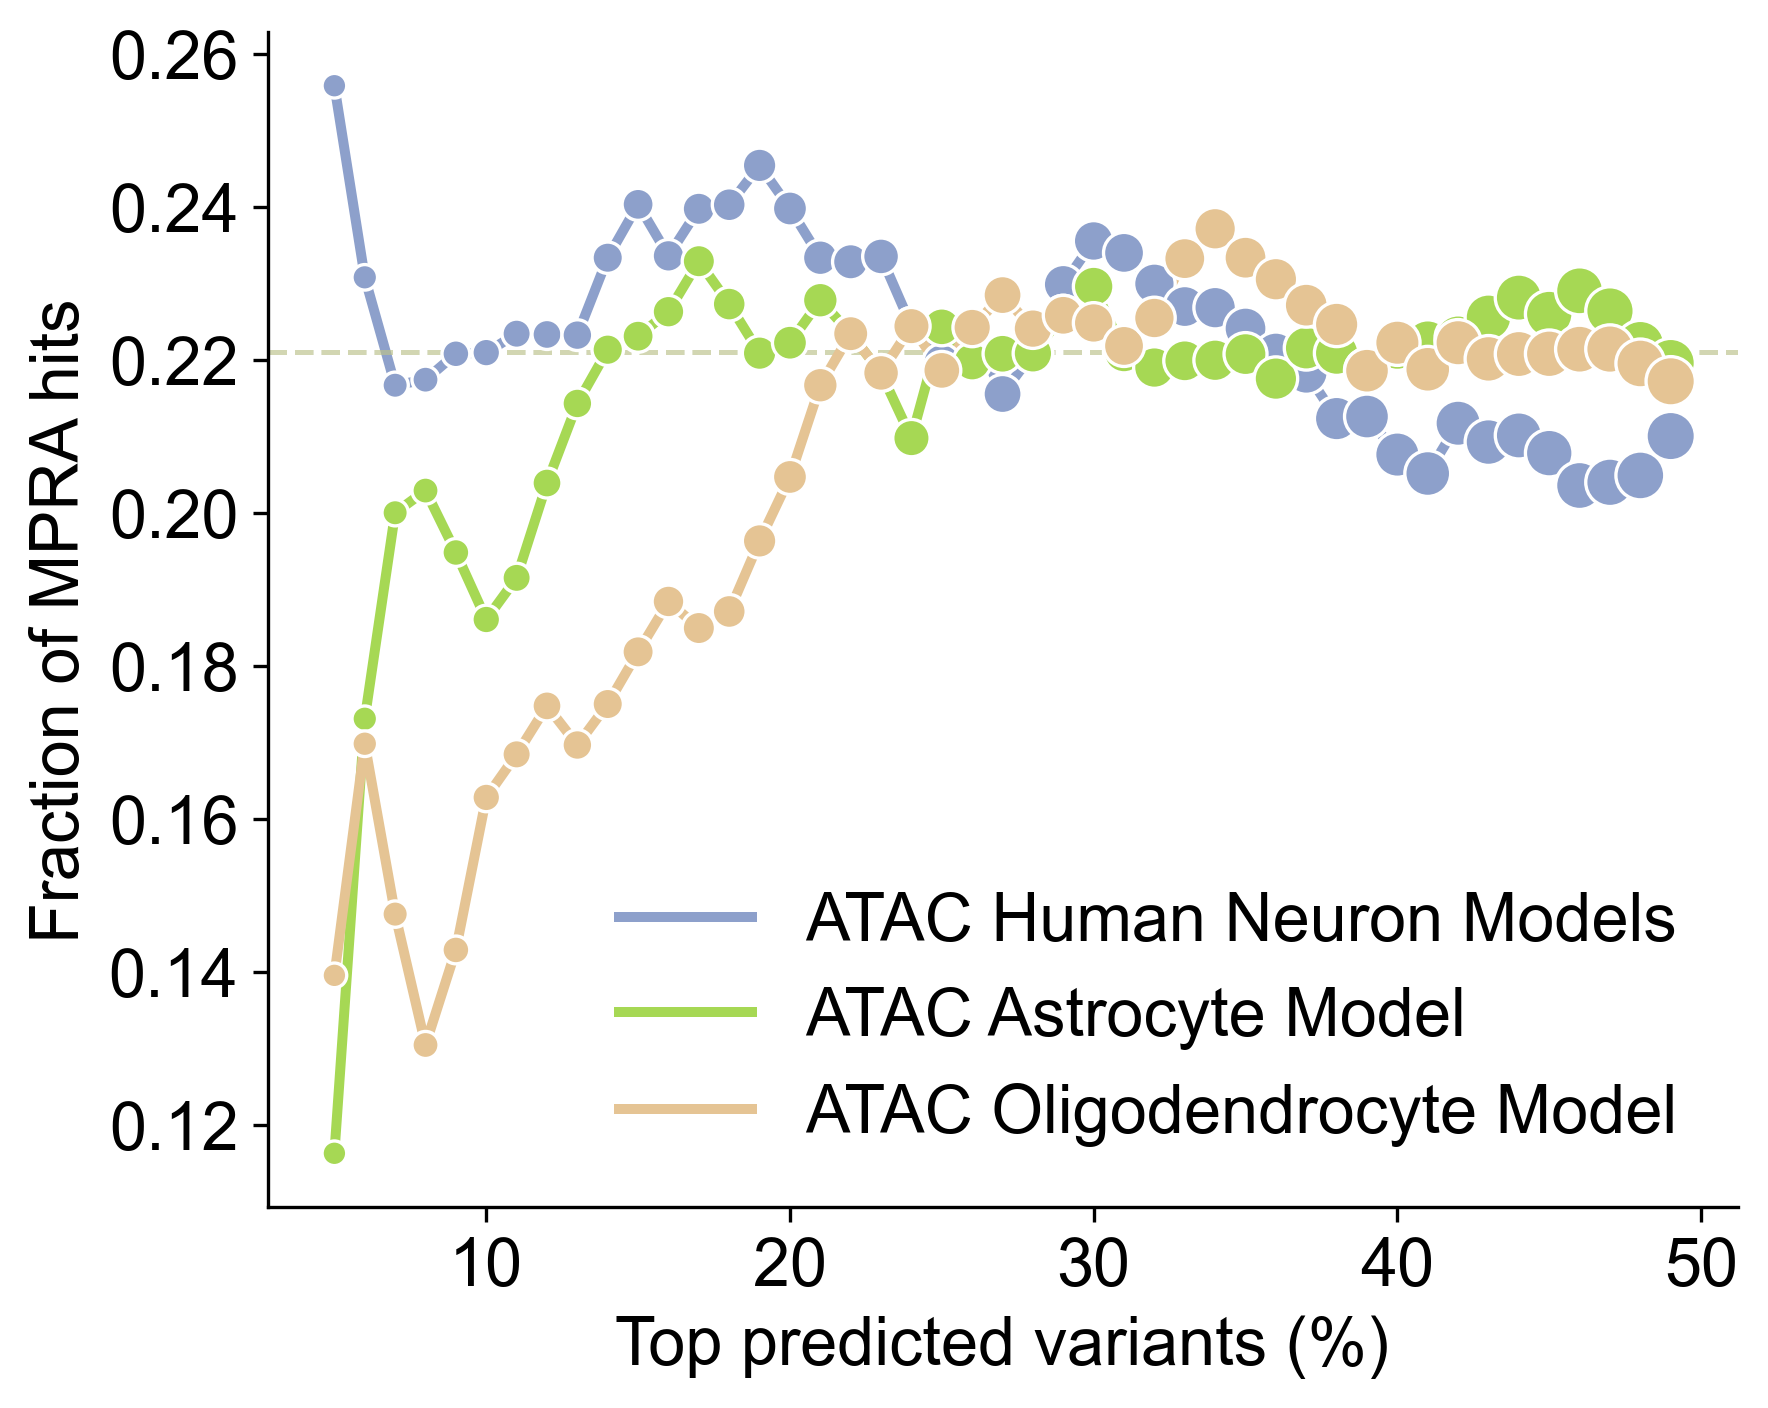

,Method,top_fraction,top_percent,n_top,n_rest,top_hit_rate,rest_hit_rate,background_hit_rate,odds_ratio,Fisher_p,FDR,point_size
0,ATAC Human Neuron Models,0.05,5.0,43,812,0.255814,0.219212,0.221053,1.224368,0.343912,0.856115,35.000000
1,ATAC Human Neuron Models,0.06,6.0,52,803,0.230769,0.220423,0.221053,1.061017,0.487896,0.856115,37.513298
2,ATAC Human Neuron Models,0.07,7.0,60,795,0.216667,0.221384,0.221053,0.972800,0.587535,0.856115,39.747340
3,ATAC Human Neuron Models,0.08,8.0,69,786,0.217391,0.221374,0.221053,0.977011,0.581108,0.856115,42.260638
4,ATAC Human Neuron Models,0.09,9.0,77,778,0.220779,0.221080,0.221053,0.998256,0.550973,0.856115,44.494681
...,...,...,...,...,...,...,...,...,...,...,...,...
130,ATAC Oligodendrocyte Model,0.45,45.0,385,470,0.220779,0.221277,0.221053,0.997115,0.539318,0.856115,130.505319
131,ATAC Oligodendrocyte Model,0.46,46.0,393,462,0.221374,0.220779,0.221053,1.003460,0.524137,0.856115,132.739362
132,ATAC Oligodendrocyte Model,0.47,47.0,402,453,0.221393,0.220751,0.221053,1.003738,0.523538,0.856115,135.252660
133,ATAC Oligodendrocyte Model,0.48,48.0,410,445,0.219512,0.222472,0.221053,0.982955,0.573786,0.856115,137.486702


In [7]:
import numpy as np
import pandas as pd
import seaborn as sns


# ============================================================
# 1. Load brain MPRA data
# ============================================================

df = pd.read_csv(
    "../../mpra3_lib_analysis/allele_differences_withoutcontrol/"
    "20240817_allele_only_for_plotting/"
    "annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv",
    index_col=0,
)


# ============================================================
# 2. Define the three ATAC model groups
# ============================================================

score_dict = {
    "ATAC Human Neuron Models": all_p_values_atac[
        [
            "fullard_DLPFC-model-best",
            "fullard_hippocampus-model-best",
            "fullard_putamen-model-best",
        ]
    ].min(axis=1),

    "ATAC Astrocyte Model": all_p_values_atac[
        "astrocyte_GSE188398-model-best"
    ],

    "ATAC Oligodendrocyte Model": all_p_values_atac[
        "oligodendrocyte_GSE143666-model-best"
    ],
}


# ============================================================
# 3. Prepare data using your original function
# ============================================================

plot_df, score_label, metric_label = prepare_validation_df(
    df_mpra=df,
    score_dict=score_dict,
    logfc_col="logFC_converted",
    p_col="p",
    fdr_col="fdr",
    score_transform="neglog10",
    mpra_metric="abs_logFC",
    hit_fdr_threshold=0.05,
)


# ============================================================
# 4. Temporarily replace the Set2 colors used inside the
#    original plotting function
#
# Order follows score_dict:
#   1. Human neuron       -> original blue
#   2. Astrocyte          -> new yellow-green
#   3. Oligodendrocyte    -> new tan
# ============================================================

custom_colors = [
    "#8DA0CB",  # Human neuron: blue from the original figure
    "#A6D854",  # Astrocyte: color not used in the original figure
    "#E5C494",  # Oligodendrocyte: color not used in the original figure
]

original_color_palette = sns.color_palette


def temporary_color_palette(
    palette=None,
    n_colors=None,
    desat=None,
    as_cmap=False,
):
    """
    Intercept the Set2 palette requested inside the original plotting
    function, while leaving all other seaborn palette calls unchanged.
    """

    if (
        palette == "Set2"
        and not as_cmap
        and (n_colors is None or n_colors == 3)
    ):
        colors = custom_colors.copy()

        if desat is not None:
            colors = [
                sns.desaturate(color, desat)
                for color in colors
            ]

        if n_colors is not None:
            colors = colors[:n_colors]

        return colors

    return original_color_palette(
        palette=palette,
        n_colors=n_colors,
        desat=desat,
        as_cmap=as_cmap,
    )


# ============================================================
# 5. Generate the plot using your original plotting function
# ============================================================

sns.color_palette = temporary_color_palette

try:
    enrich_stats = plot_hit_enrichment_same_plot(
        plot_df,
        top_fracs=np.arange(0.05, 0.5, 0.01),
        out_file=(
            "Fig_same_plot_ATAC_humanNeuron_"
            "astrocyte_oligodendrocyte_brain_MPRA_atac.pdf"
        ),
        title="",
        show_background=True,
    )

finally:
    # Restore seaborn immediately after plotting.
    sns.color_palette = original_color_palette


display(enrich_stats)


=== MPRA hit enrichment results ===
                    Method  top_fraction  top_percent  n_top  n_rest  top_hit_rate  rest_hit_rate  background_hit_rate  odds_ratio  Fisher_p      FDR  point_size
  SHAP Human Neuron Models          0.05          5.0     44     811      0.227273       0.220715             0.221053    1.038449  0.521052 0.984274   35.279255
  SHAP Human Neuron Models          0.06          6.0     52     803      0.269231       0.217933             0.221053    1.322105  0.240091 0.984274   37.513298
  SHAP Human Neuron Models          0.07          7.0     60     795      0.250000       0.218868             0.221053    1.189655  0.337100 0.984274   39.747340
  SHAP Human Neuron Models          0.08          8.0     69     786      0.231884       0.220102             0.221053    1.069691  0.460802 0.984274   42.260638
  SHAP Human Neuron Models          0.09          9.0     78     777      0.217949       0.221364             0.221053    0.980271  0.575784 0.984274   4

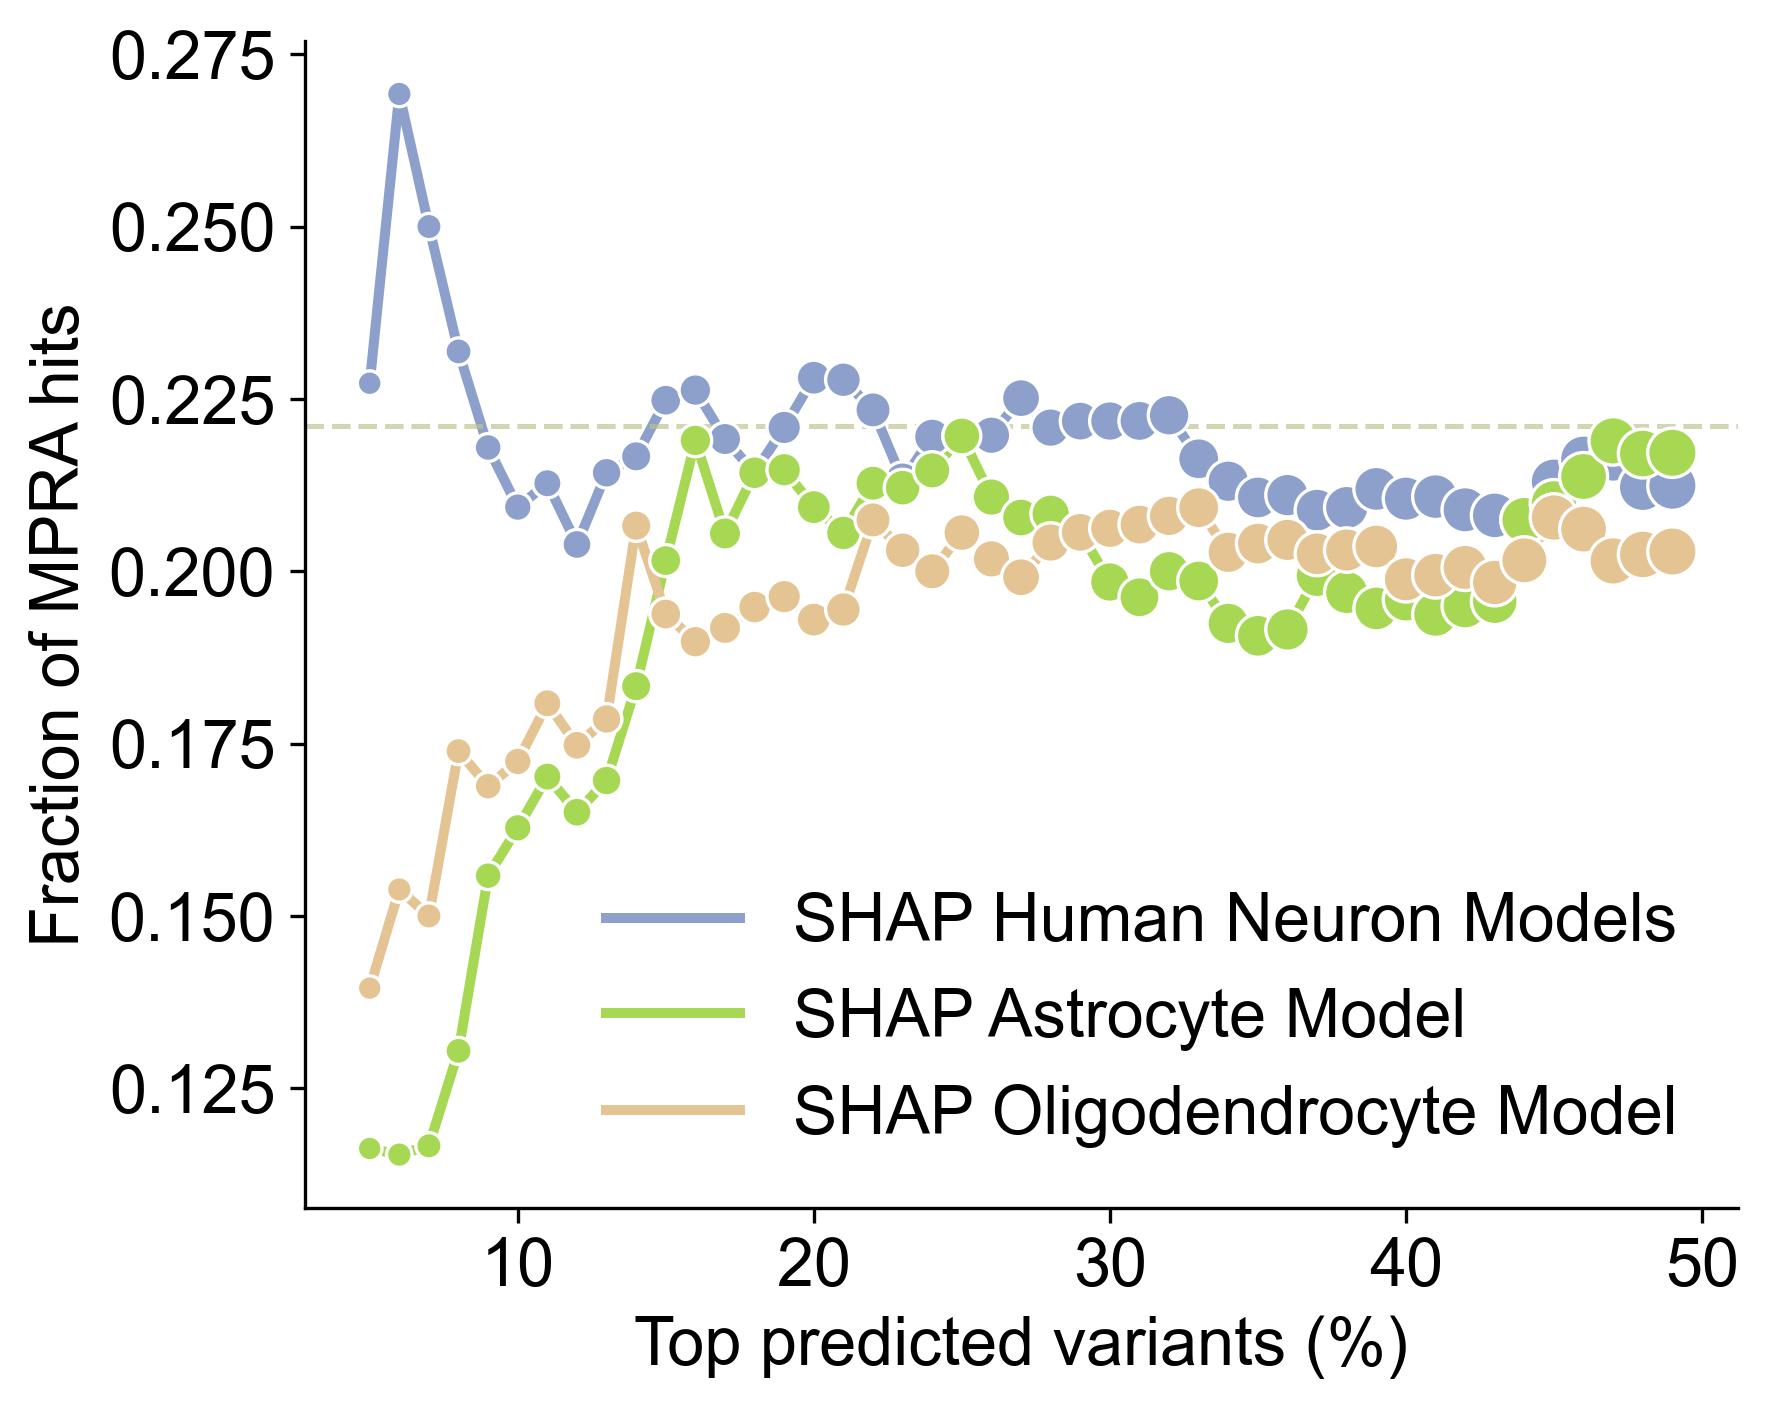

,Method,top_fraction,top_percent,n_top,n_rest,top_hit_rate,rest_hit_rate,background_hit_rate,odds_ratio,Fisher_p,FDR,point_size
0,SHAP Human Neuron Models,0.05,5.0,44,811,0.227273,0.220715,0.221053,1.038449,0.521052,0.984274,35.279255
1,SHAP Human Neuron Models,0.06,6.0,52,803,0.269231,0.217933,0.221053,1.322105,0.240091,0.984274,37.513298
2,SHAP Human Neuron Models,0.07,7.0,60,795,0.250000,0.218868,0.221053,1.189655,0.337100,0.984274,39.747340
3,SHAP Human Neuron Models,0.08,8.0,69,786,0.231884,0.220102,0.221053,1.069691,0.460802,0.984274,42.260638
4,SHAP Human Neuron Models,0.09,9.0,78,777,0.217949,0.221364,0.221053,0.980271,0.575784,0.984274,44.773936
...,...,...,...,...,...,...,...,...,...,...,...,...
130,SHAP Oligodendrocyte Model,0.45,45.0,385,470,0.207792,0.231915,0.221053,0.868702,0.823370,0.984274,130.505319
131,SHAP Oligodendrocyte Model,0.46,46.0,393,462,0.206107,0.233766,0.221053,0.850962,0.854105,0.984274,132.739362
132,SHAP Oligodendrocyte Model,0.47,47.0,402,453,0.201493,0.238411,0.221053,0.806075,0.916540,0.984274,135.252660
133,SHAP Oligodendrocyte Model,0.48,48.0,410,445,0.202439,0.238202,0.221053,0.811754,0.910247,0.984274,137.486702


In [8]:
import numpy as np
import pandas as pd
import seaborn as sns

# ============================================================
# 1. Load THP-1 MPRA results
# ============================================================

df = pd.read_csv(
    "../../mpra3_lib_analysis/allele_differences_withoutcontrol/"
    "20240817_allele_only_for_plotting/"
    "annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv",
    index_col=0,
)

# ============================================================
# 2. Define SHAP model groups
#    Keep only:
#    - Human neuron
#    - Astrocyte
#    - Oligodendrocyte
# ============================================================

score_dict = {
    "SHAP Human Neuron Models": all_p_values_shap[
        [
            "fullard_DLPFC-model-best_SHAP",
            "fullard_hippocampus-model-best_SHAP",
            "fullard_putamen-model-best_SHAP",
        ]
    ].min(axis=1),

    "SHAP Astrocyte Model": all_p_values_shap[
        "astrocyte_GSE188398-model-best_SHAP"
    ],

    "SHAP Oligodendrocyte Model": all_p_values_shap[
        "oligodendrocyte_GSE143666-model-best_SHAP"
    ],
}

# ============================================================
# 3. Prepare validation dataframe using your original function
# ============================================================

plot_df, score_label, metric_label = prepare_validation_df(
    df_mpra=df,
    score_dict=score_dict,
    logfc_col="logFC_converted",
    p_col="p",
    fdr_col="fdr",
    score_transform="neglog10",
    mpra_metric="abs_logFC",
    hit_fdr_threshold=0.05,
)

# ============================================================
# 4. Temporarily override Set2 palette inside the original
#    plotting function so colors stay exactly as desired
#
#    Order follows score_dict:
#    1. SHAP Human Neuron Models      -> blue
#    2. SHAP Astrocyte Model          -> yellow-green
#    3. SHAP Oligodendrocyte Model    -> tan
# ============================================================

custom_colors = [
    "#8DA0CB",  # Human neuron
    "#A6D854",  # Astrocyte
    "#E5C494",  # Oligodendrocyte
]

original_color_palette = sns.color_palette


def temporary_color_palette(
    palette=None,
    n_colors=None,
    desat=None,
    as_cmap=False,
):
    """
    Intercept the Set2 palette requested inside the original plotting
    function, while leaving all other seaborn palette calls unchanged.
    """
    if (
        palette == "Set2"
        and not as_cmap
        and (n_colors is None or n_colors == 3)
    ):
        colors = custom_colors.copy()

        if desat is not None:
            colors = [
                sns.desaturate(color, desat)
                for color in colors
            ]

        if n_colors is not None:
            colors = colors[:n_colors]

        return colors

    return original_color_palette(
        palette=palette,
        n_colors=n_colors,
        desat=desat,
        as_cmap=as_cmap,
    )

# ============================================================
# 5. Plot using your original plotting function
# ============================================================

sns.color_palette = temporary_color_palette

try:
    enrich_stats = plot_hit_enrichment_same_plot(
        plot_df,
        top_fracs=np.arange(0.05, 0.5, 0.01),
        out_file="Fig_same_plot_SHAP_humanNeuron_astrocyte_oligodendrocyte_thp1_MPRA.pdf",
        title="",
        show_background=True,
    )
finally:
    sns.color_palette = original_color_palette

display(enrich_stats)

## Absolute allelic-effect comparison between MPRA and machine-learning models

Run the notebook from the beginning through the ATAC and SHAP calculation cells before running the cells below. The comparison uses context-matched model groups:

- THP-1 MPRA versus THP-1 ATAC-prediction or SHAP models.
- Brain-tissue MPRA versus human-neuron ATAC-prediction or SHAP models.

For each variant and model group, the model with the smallest machine-learning p-value is selected, and the absolute effect from that same model is used. All tested variants are plotted; MPRA-significant variants are highlighted. Correlations are also reported separately for all variants and for MPRA-significant variants.

In [9]:
# Validate that the ATAC and SHAP cells above were run with the patched variable names.
required_objects = {
    "all_p_values_atac": "ATAC p-values",
    "all_atac_effect": "ATAC absolute effects",
    "all_p_values_shap": "SHAP p-values",
    "all_shap_effect_final": "SHAP absolute effects",
}

missing = [name for name in required_objects if name not in globals()]
if missing:
    raise NameError(
        "Missing required objects: " + ", ".join(missing) +
        ". Run the ATAC and SHAP calculation cells above first."
    )

for name, description in required_objects.items():
    obj = globals()[name]
    if not isinstance(obj, pd.DataFrame):
        raise TypeError(f"{name} must be a pandas DataFrame, not {type(obj).__name__}.")
    print(f"{description}: {obj.shape}")

print("\nATAC model columns:")
print(all_atac_effect.columns.tolist())
print("\nSHAP model columns:")
print(all_shap_effect_final.columns.tolist())

ATAC p-values: (855, 20)
ATAC absolute effects: (855, 20)
SHAP p-values: (855, 20)
SHAP absolute effects: (855, 20)

ATAC model columns:
['H1_IFNB-model-best', 'H1_resting-model', 'HEK293_ATAC_high_depth0729', 'HEK293T_ATAC', 'Mouse_Cortex_AgeB-model', 'Mouse_Cortex_AgeC-model', 'Mouse_Striatum_AgeB', 'Mouse_Striatum_AgeC', 'THP1_IFNB-Calvin', 'THP1_IFNG-Calvin', 'THP1_LPSIFNG-Calvin', 'THP1_monocyte0729', 'THP1_Naive-Calvin', 'WTC11_IFNB', 'WTC11_resting', 'fullard_DLPFC-model-best', 'fullard_hippocampus-model-best', 'fullard_putamen-model-best', 'astrocyte_GSE188398-model-best', 'oligodendrocyte_GSE143666-model-best']

SHAP model columns:
['fullard_DLPFC-model-best_SHAP', 'fullard_hippocampus-model-best_SHAP', 'fullard_putamen-model-best_SHAP', 'H1_IFNB-model-best_SHAP', 'THP1_IFNB-model-best_SHAP', 'H1_resting-model-best_SHAP', 'THP1_IFNG-model-best_SHAP', 'HEK293_ATAC_high_depth0729-model-best_SHAP', 'THP1_LPSIFNG_Calvin_SHAP', 'HEK293T_ATAC-model-best_SHAP', 'THP1_monocyte0729-mod

### Interpretation note

MPRA log fold change, predicted accessibility difference and SHAP attribution are on different numerical scales. The plots therefore evaluate whether variants with larger absolute MPRA allelic effects also tend to have larger absolute machine-learning effects; they do not test agreement with the identity line.